# Surivial Analysis Pipeline Ver2.7

# Import packages

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import xgboost as xgb
import yaml
from lifelines import CoxPHFitter, KaplanMeierFitter
from lifelines.utils import concordance_index
from sklearn.metrics import average_precision_score, auc, confusion_matrix, f1_score, precision_recall_curve, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

import copy
from dataclasses import dataclass
from enum import Enum
import os
import time

# Global constants

In [ ]:
# Fixed constants
YEAR_DAYS = 365.25
HALF_YEAR_DAYS = YEAR_DAYS / 2
TEMP_HORIZON_CAP = 5.0
img_emb_path = "<PRIVATE_DATA_PATH>"

-----------------

# 1. Data processing

## 1.1 Load data

In [ ]:
# Load once-preprocessed clinical data (filtered data with basic labels and observation-time columns built)
clinical_raw_data_full = pd.read_csv('<PRIVATE_DATA_PATH>')
# clinical_raw_data_full.head()

In [ ]:
# Restrict clinical records to patients with available CT imaging
smaller_raw_data_id = pd.read_csv("<PRIVATE_DATA_PATH>")
valid_ids = set(smaller_raw_data_id["pat_id"].astype(str))
clinical_raw_data_small = clinical_raw_data_full[
    clinical_raw_data_full["pat_id"].astype(str).isin(valid_ids)
].copy()
print("Original clinical size:", len(clinical_raw_data_full))
print("CT-available size:", len(clinical_raw_data_small))

Original clinical size: 4904
CT-available size: 2023


In [ ]:
# We will load the same dataset split with Image processing, ensuring no data leakage.
# Because the image embedding are generated by training a survial model with train set and evaluted by val set,
# if we don't reuse the split, then the new testset may contains datapoints in previous val set, causing up biased AUC.
def load_ids(path):
    s = pd.read_csv(path, header=None)[0].astype(str)
    return s[s != "0"]   # drop header artifact

train_pid = load_ids("<PRIVATE_DATA_PATH>")
val_pid   = load_ids("<PRIVATE_DATA_PATH>")
test_pid  = load_ids("<PRIVATE_DATA_PATH>")

print(len(train_pid), len(val_pid), len(test_pid))
assert len(train_pid)+ len(val_pid)+ len(test_pid) == len(clinical_raw_data_small), "split size sum match clinical data size"

1213 405 405


In [6]:
# clinical_raw_data_small[clinical_raw_data_small["time_to_event"] != clinical_raw_data_small["time_of_observation"]]["cp_label"].value_counts()
# clinical_raw_data_small[clinical_raw_data_small["time_to_event"] == clinical_raw_data_small["time_of_observation"]]["cp_label"].value_counts()
# clinical_raw_data_small["cp_label"].value_counts()

## 1.2 Remove ineligible patients

In [ ]:
def drop_ineligible_data(df, strict_cls=False, window_year = None, min_gap_days=HALF_YEAR_DAYS, verbose=True):
    """
    Unified drop-ineligible function for BOTH survival and classification tasks.

    Always drops:
        • Prevalent CP
        • Early CP (< min_gap_days)
        • Zero follow-up censored cases

    If strict_cls=True (for strict classification):
        • Keep only:
             - CP events within window (event=1)
             - OR non-events with follow-up ≥ window (event=0)

    Arguments:
        strict_cls : whether to apply strict classification eligibility
        window_year : required if strict_cls=True
    """
    # Exclude ineligible patients with prevalent CP 
    # (patients who having CP record before the 1st AP offer no info for predicting incident CP)
    prevalent_cp_mask = df["prevalent_cp"] == 1
    result = df.loc[~prevalent_cp_mask].copy()

    # Exclude patients with CP events within minimal gap period (within half year of baseline AP), 
    # potentially prevalent cases misclassified as incident cases
    invalid_cp_event_mask = (
        (result["cp_after_first_ap"] == 1) &
        (result["time_to_event"] >= 0) &
        (result["time_to_event"] < min_gap_days)
    )
    result = result.loc[~invalid_cp_event_mask]#.copy()

    # Exclude censored patients with zero follow-up time
    zero_followup_mask = (result["cp_after_first_ap"] == 0) & (result["time_of_observation"] == 0)
    result = result.loc[~zero_followup_mask].copy()

    # strict classification eligibility
    if strict_cls:
        if window_year is None:
            raise ValueError("strict_cls=True requires window_year.")
        window_days = window_year * YEAR_DAYS

        # event_xgb: CP happened within the window (event=1)
        event_xgb = (
            (result["cp_after_first_ap"] == 1) &
            (result["time_to_event"] <= window_days)
        )

        # case 2: CP happened AFTER window → negative label (event=0) (keep)
        cp_after_window = (
            (result["cp_after_first_ap"] == 1) &
            (result["time_to_event"] > window_days)
        )

        # case 3: No CP but sufficient follow-up → negative label (event=0) (keep)
        no_event_sufficient_fu = (
            (result["cp_after_first_ap"] == 0) &
            (result["time_of_observation"] >= window_days)
        )

        # Final strict mask: keep only valid positives or valid negatives
        strict_mask = event_xgb | cp_after_window | no_event_sufficient_fu
        result = result.loc[strict_mask].copy()
    
    if verbose:
        dropped_prevalent_cp = prevalent_cp_mask.sum()
        dropped_invalid_cp = invalid_cp_event_mask.sum()
        dropped_no_followup = zero_followup_mask.sum()
        print(f"  Dropped prevalent CP:    {dropped_prevalent_cp}")
        print(f"  Dropped early CP (<{min_gap_days}d): {dropped_invalid_cp}")
        print(f"  Dropped zero follow-up for uncensored:  {dropped_no_followup}")
        if strict_cls:
            dropped_strict = (~strict_mask).sum()
            print(f"  Dropped strict-CLS ineligible: {dropped_strict} (after prior filtering)")
        print(f"Use {len(result)} eligible records from {len(df)} records for next preprocessing.\n" + "-"*100)
    return result

In [8]:
# eligible = drop_ineligible_data(clinical_raw_data, verbose=True, strict_cls=False)

## 1.3 Build targets

In [9]:
class LabelMethod(Enum):
    CLASSIC_SURVIVAL      = "classic_survival"      
    FIXED_WINDOW_SURVIVAL = "fixed_window_survival" 
    OPTIMISTIC_WINDOW     = "optimistic_window_survival"     

### 1.3.1 classic_survival

**Classic survival labeling** treats CP as a standard time-to-event problem without imposing a fixed prediction window.

- **Event (`event`)**  
  The event indicator is set directly from the observed CP diagnosis label.
  - `event = 1` if CP is observed
  - `event = 0` otherwise

- **Duration (`duration`)**  
  The duration is defined as:
  - time from baseline to CP diagnosis for event cases, or
  - time from baseline to last clinical observation for censored cases.

- **Key property**  
  This labeling does **not** depend on a prediction horizon (`window_year`) and preserves the full follow-up time for each patient.

This labeling scheme is compatible with standard Cox-type and deep survival models, but **NOT** used for XGBoost. (Because XGB need to setup horizon to define label)

In [10]:
def construct_targets_classic(df, verbose=True):
    df = df.copy()
    duration = df["time_to_event"].fillna(df["time_of_observation"]) / YEAR_DAYS
    event = df["cp_label"].astype(int)

    if verbose:
        print(f"Constructed targets with {LabelMethod.CLASSIC_SURVIVAL.value} labeling, no need for window_year." +
               "\n" + "-"*100)
    return duration.values, event.values

### 1.3.2 Fixed-Window Survival

**Fixed-window survival labeling** reformulates the survival task to predict whether CP occurs **within a predefined time window** $T$ (in years).

Let $T$ denote the window horizon.

- **Event (`event`)**
  - `event = 1` if CP occurs within $T$
  - `event = 0` otherwise

- **Duration (`duration`)**
  - If CP occurs before $T$: duration equals the true event time
  - If CP occurs after $T$: duration is truncated to $T$
  - If the patient is censored before $T$: duration equals the censoring time
  - If the patient is censored after $T$: duration is truncated to $T$

- **Key property**

  All durations are truncated at the fixed window $T$, ensuring consistent risk horizons across patients while preserving true event times when they occur within the window. Or we don't care about anything happened beyond window $T$ because they are not aligned with our objective in this label method- Whether CP occurs **within a predefined time window** $T$ (in years).

This formulation enables horizon-specific survival modeling and aligns with standard fixed-window survival analysis.

In [11]:
def construct_targets_fixed_window(df, window_year, verbose=True):
    if window_year is None:
        raise ValueError(f"Please provide window_year for {LabelMethod.FIXED_WINDOW_SURVIVAL.value} labeling.")
    window_days = window_year * YEAR_DAYS

    df = df.copy()

    # duration: use time_to_event if available, otherwise censoring duration (time_of_observation)
    # time_of_observation is the time from baseline AP to last follow-up for those without event (no CP in last follow-up)
    df['duration'] = df['time_to_event'].fillna(df['time_of_observation'])

    # event indicator: cp event within specified time window (included)
    df["event"] = ((df["time_to_event"] > 0) & 
            (df["time_to_event"] <= window_days)).astype(int)

    # Truncate durations based on the specified time window
    df['duration'] = np.minimum(df["duration"], window_days)
    df['duration'] /= YEAR_DAYS  # convert duration to years

    if verbose:
        print(f"Constructed targets with {LabelMethod.FIXED_WINDOW_SURVIVAL.value} labeling with window_year={window_year}." +
               "\n" + "-"*100)

    return df['duration'].values, df['event'].values

### 1.3.3 optimistic_window_survival

**Optimistic window labeling** is a horizon-based target construction designed primarily for **classification-style objectives**, rather than standard survival analysis.

Let $T$ denote the prediction window.

- **Event (`event`)**
  - `event = 1` if CP occurs within $T$
  - `event = 0` otherwise

- **Duration (`duration`)**
  - If CP occurs within $T$: duration equals the true event time
  - If CP occurs after $T$: duration is right-truncated at $T$
  - If the patient is censored at any time before $T$: duration is set/capped to $T$

- **Key properties**
  - All non-events are assigned a duration of $T$, regardless of their actual censoring time.
  - This construction reduces variability introduced by early censoring and aligns better with fixed-horizon classification objectives.
  - As a result, early-censored patients are treated optimistically as event-free up to $T$, which may bias estimated risk downward.
  - Compared to `Fixed-window survival`, this method applies a capping besides the truncation.

This labeling strategy is intentionally asymmetric and should be interpreted as a **classification-oriented approximation**, rather than a fully principled survival formulation.

- Example:
    - A patient censored at 0.5 years → treated as censored at 5 years
    - A patient censored at 3 years → treated as censored at 5 years
    - A patient censored at 9 years → treated as censored at 5 years

In [12]:
def construct_targets_optimistic_window(df, window_year=None, verbose=True):
    if window_year is None:
        raise ValueError(f"Please provide window_year for {LabelMethod.OPTIMISTIC_WINDOW.value} labeling.")

    df = df.copy()

    #  if NaN → censor at window boundary (horizon)
    #  any duration > window → clip to window
    time_years = df["time_to_event"] / YEAR_DAYS     # may contain NaNs

    window_year_float = float(window_year)

    # If no CP → time_to_event NaN → set as censoring at horizon 
    duration = time_years.fillna(window_year_float)
    # If CP occurs AFTER window → set as censoring at horizon 
    duration = duration.clip(upper=window_year_float)

    # event = 1 only if CP happened within window
    event = (
        (df["time_to_event"].notna()) & 
        (df["time_to_event"] > 0) &
        (df["time_to_event"] / YEAR_DAYS <= window_year)
    ).astype(int)

    if verbose:
        print(f"Constructed targets with {LabelMethod.OPTIMISTIC_WINDOW.value} labeling with window_year={window_year}." +
               "\n" + "-"*100)

    return duration.values.astype(float), event.values.astype(int)

In [13]:
TARGET_BUILDERS = {
    LabelMethod.CLASSIC_SURVIVAL: construct_targets_classic,
    LabelMethod.FIXED_WINDOW_SURVIVAL: construct_targets_fixed_window,
    LabelMethod.OPTIMISTIC_WINDOW: construct_targets_optimistic_window,
}

In [14]:
# eligible = clinical_raw_data.copy()
# builder = TARGET_BUILDERS[LabelMethod.OPTIMISTIC_WINDOW]
# durations, events = builder(eligible,5)

### 1.3.4 follow-up Distribution Plot 

In [15]:
eligible = clinical_raw_data_small.copy()

Number of non-CP patients: 1766


count    1766.000000
mean        1.914034
std         3.364064
min         0.002738
25%         0.019165
50%         0.250513
75%         2.158111
max        41.259411
Name: duration_years, dtype: float64


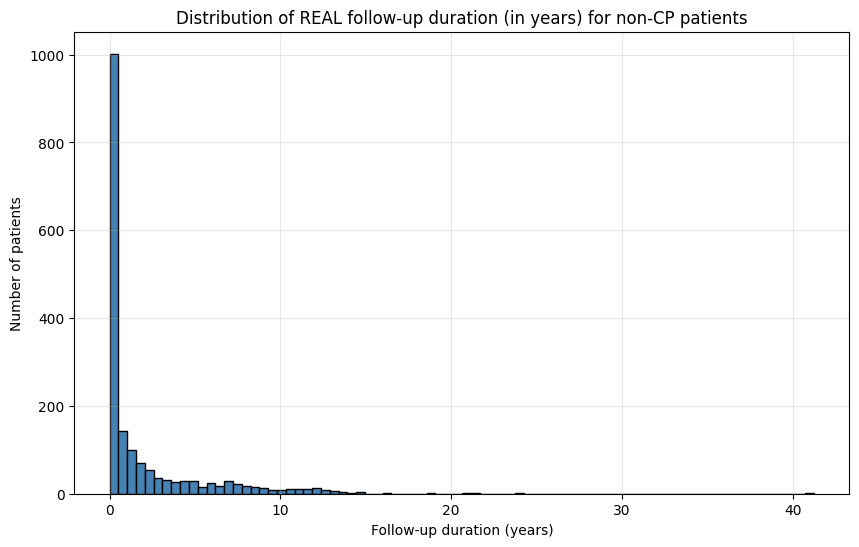

In [16]:
# eligible = drop_ineligible_data(clinical_raw_data, verbose=True, strict_cls=False)
# ---- 1. Ensure eligible dataset has already passed drop_ineligible_data() ----
df = eligible.copy()

# ---- 2. Compute duration (in years), cleanly ----
# If CP occurred → use time_to_event
# If no CP → use time_of_observation
df['duration_years'] = (
    df['time_to_event'].fillna(df['time_of_observation']) / YEAR_DAYS
)

# ---- 3. Filter to non-CP patients ----
no_cp_mask = df["cp_label"] == 0
duration_no_cp_years = df.loc[no_cp_mask, "duration_years"]

print("Number of non-CP patients:", duration_no_cp_years.shape[0])
print(duration_no_cp_years.describe())

# ---- 4. Plot histogram (in DAYS) ----
plt.figure(figsize=(10, 6))
plt.hist(duration_no_cp_years, bins=80, color='steelblue', edgecolor='black')
plt.xlabel("Follow-up duration (years)")
plt.ylabel("Number of patients")
plt.title("Distribution of REAL follow-up duration (in years) for non-CP patients")
plt.grid(alpha=0.3)
plt.show()

## 1.4 Clinical Feature Overview

In [17]:
CLINICAL_FEATURES = ['age',
 'race',
 'ethnicity',
 'sex',
 'weight_kg',
 'height_cm',
 'AMYLASE',
 'CREATININE',
 'GLUCOSE',
 'LIPASE',
 'ever_taken_pancreatic_enzymes',
 'num_prescriptions',
 'num_cholecystectomies',
 'max_tobacco',
 'max_smokeless',
 'max_alcohol',
 'ever_iv_drug',
 'ever_sexually_active']

In [18]:
len(CLINICAL_FEATURES)

18

In [19]:
def get_raw_features(df, verbose=True):
    df_result = df.copy()
    df_result = df_result[CLINICAL_FEATURES]
    if verbose:
        print(f"Obtained features columns: {df_result.columns.tolist()}")
    return df_result

get_raw_features(eligible).info()


Obtained features columns: ['age', 'race', 'ethnicity', 'sex', 'weight_kg', 'height_cm', 'AMYLASE', 'CREATININE', 'GLUCOSE', 'LIPASE', 'ever_taken_pancreatic_enzymes', 'num_prescriptions', 'num_cholecystectomies', 'max_tobacco', 'max_smokeless', 'max_alcohol', 'ever_iv_drug', 'ever_sexually_active']
<class 'pandas.core.frame.DataFrame'>
Index: 2023 entries, 0 to 4903
Data columns (total 18 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   age                            2023 non-null   float64
 1   race                           2018 non-null   object 
 2   ethnicity                      1992 non-null   object 
 3   sex                            2023 non-null   float64
 4   weight_kg                      1978 non-null   float64
 5   height_cm                      1958 non-null   float64
 6   AMYLASE                        767 non-null    float64
 7   CREATININE                     1925 non-null   float

## 1.5 Preprocess features for MLP 

### 1.5.1 build date related features

In [ ]:
temp = eligible.copy()
temp['first_ap_year'] = pd.to_datetime(temp['first_ap']).dt.year
temp['ap_period'] = pd.cut(temp['first_ap_year'],
                               bins=[1990, 2000, 2010, 2020, 2030],
                               labels=['1990s', '2000s', '2010s', '2020s'])
temp['ap_period'].value_counts()

We add a binary time-period indicator capturing whether the patient’s first acute pancreatitis (AP) episode occurred in or after 2020, reflecting cohort-era effects without using any post-baseline outcome information.

In [ ]:
def construct_time_period_feature(raw_df, feature_df, verbose=True):
    feature_df = feature_df.copy()
    first_ap_year = pd.to_datetime(raw_df['first_ap']).dt.year
    feature_df['first_ap_in_and_after_2020'] = (first_ap_year >= 2020).astype(int)

    if verbose:
        print("Constructed time period feature: 'first_ap_in_and_after_2020'")
    return feature_df

construct_time_period_feature(eligible, get_raw_features(eligible, verbose=False)).head()

### 1.5.2 process category features

In [ ]:
print(len(eligible["race"].unique()))
eligible["race"].unique()

In [ ]:
len(eligible["ethnicity"].unique())

To reduce sparsity in `race` fields, we standardize race information into a small set of categories.

In [24]:
def clean_race_category(x):
    if pd.isna(x): return 'Other/Unknown'
    x = x.lower()
    if 'white' in x: return 'White'
    if 'black' in x: return 'Black'
    if 'asian' in x or 'chinese' in x or 'filipino' in x or 'korean' in x or 'japanese' in x:
        return 'Asian'
    if 'hispanic' in x or 'latino' in x or 'spanish' in x:
        return 'Hispanic/Latino'
    if 'indigenous' in x:
        return 'Indigenous'
    return 'Other/Unknown'

# ethinicity is way more noisy, not used for now
# def clean_ethnicity(x):
#     if pd.isna(x): return np.nan
#     x = x.lower()
#     if 'not' in x or "?" in x: return 'Other/Unknown'
#     if 'white' in x: return 'White'
#     if 'black' in x: return 'Black'
#     if 'latino' in x:
#         return 'Hispanic/Latino'
#     return 'Other/Unknown'

def clean_categorical_features(feature_df):
    feature_df = feature_df.copy()
    feature_df['race_clean'] = feature_df['race'].apply(clean_race_category)
    # feature_df['ethnicity_clean'] = feature_df['ethnicity'].apply(clean_ethnicity)

    feature_df = feature_df.drop(columns=['race', 'ethnicity'])
    return feature_df

In [25]:
clean_categorical_features(eligible)["race_clean"].unique()

array(['White', 'Hispanic/Latino', 'Asian', 'Other/Unknown', 'Black',
       'Indigenous'], dtype=object)

**Note**: One-Hot Encoding of Categorical Features

Categorical features are transformed using one-hot encoding to produce model-ready numerical inputs.

- The encoder is **fit on the training set only** and reused for validation and test sets.
- This ensures a **consistent feature dimension and category ordering** across all splits.
- Unseen categories in validation or test data are safely ignored during transformation.

This workflow prevents information leakage while maintaining compatibility between training and inference.

In [26]:
def construct_categorical_features(df, train = True, encoder=None, verbose=True):
    df_out = df.copy()

    # Step 1 — clean category
    df_out = clean_categorical_features(df_out)  
    categorical_cols = ["race_clean"]

    if train:
        # fit the encoder
        encoder = OneHotEncoder(
            drop='first',
            handle_unknown='ignore',
            sparse_output=False
        )
        encoded = encoder.fit_transform(df_out[categorical_cols])
    else:
        # use existing encoder
        encoded = encoder.transform(df_out[categorical_cols])

    # one-hot column names
    encoded_cols = encoder.get_feature_names_out()

    # drop original column & attach OHE
    df_out = pd.concat(
        [
            df_out.drop(columns=categorical_cols).reset_index(drop=True),
            pd.DataFrame(encoded, columns=encoded_cols)
        ],
        axis=1
    )

    if verbose:
        print(f"Constructed categorical features with one-hot encoding. "
              f"(train={train}, cols={len(encoded_cols)})")
    # return encoder after fitting with training set
    if train:
        return df_out, encoder
    else:
        return df_out, None

construct_categorical_features(eligible)[0].info()

Constructed categorical features with one-hot encoding. (train=True, cols=5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2023 entries, 0 to 2022
Data columns (total 36 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   pat_id                         2023 non-null   object 
 1   ap_date_set                    2023 non-null   object 
 2   cp_date                        257 non-null    object 
 3   days_ap_to_cp                  257 non-null    float64
 4   ap_count                       2023 non-null   int64  
 5   cp_label                       2023 non-null   int64  
 6   last_ap_date                   2023 non-null   object 
 7   age                            2023 non-null   float64
 8   sex                            2023 non-null   float64
 9   alive                          2023 non-null   int64  
 10  weight_kg                      1978 non-null   float64
 11  height_cm                      

### 1.5.3 process numerical/continuous features

#### all numerical cols

In [27]:
num_cols = [
    'age', 'sex', 'weight_kg', 'height_cm',
    'AMYLASE', 'CREATININE', 'GLUCOSE', 'LIPASE',
    'num_prescriptions', 'num_cholecystectomies',
    'max_tobacco', 'max_smokeless', 'max_alcohol',
    'ever_iv_drug', 'ever_sexually_active'
]

#### Plot distributions

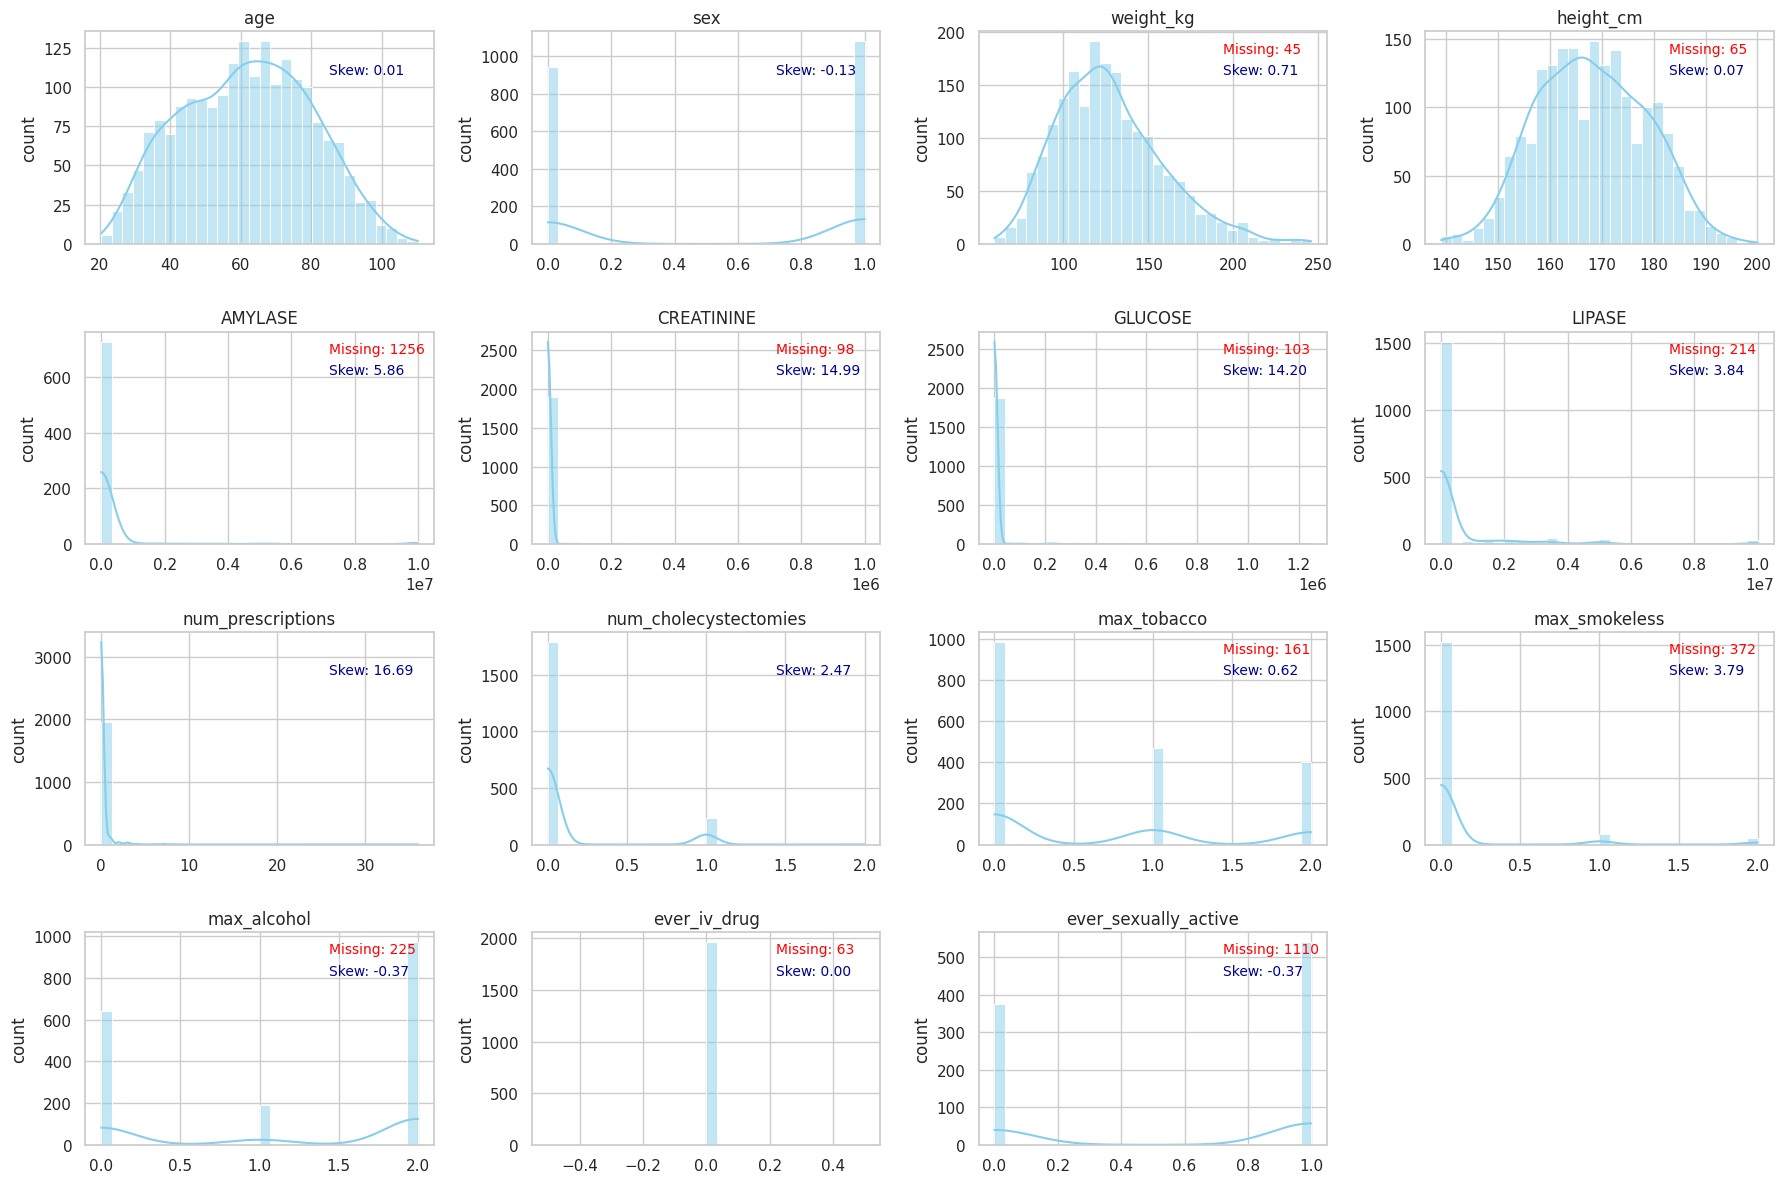

In [ ]:
# general style
sns.set(style="whitegrid", palette="muted", color_codes=True)

n = len(num_cols)
ncols = 4
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 3))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(
        eligible[col], kde=True, bins=30, ax=axes[i], color='skyblue'
    )
    axes[i].set_title(col)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("count")
    if eligible[col].isnull().sum() > 0:
        axes[i].annotate(
            f"Missing: {eligible[col].isnull().sum()}",
            xy=(0.7, 0.9), xycoords='axes fraction',
            fontsize=10, color='red'
        )

    skew_val = eligible[col].dropna().skew()
    axes[i].annotate(
        f"Skew: {skew_val:.2f}",
        xy=(0.7, 0.8), xycoords='axes fraction',
        fontsize=10, color='darkblue'
    )

# turn off any empty subplots
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

#### Processing continuous columns

For continuous columns, deal with nan values because MLP cannot accept nan values, solve skewness, then apply standardlization.

In [29]:
def preprocess_continuous_features(df, fitted_stats = None, train = True, verbose=True):
    """
    Directly preprocess continuous columns:
    - Fill NaN with median
    - Apply log1p to heavily skewed columns
    - Standardize each column (mean 0, std 1)
    - If train=True: computes medians/means/stds from df and returns them for reuse.
    - If train=False: applies provided fitted_stats to transform df.
    """

    # define feature groups
    heavy_skewed_cols = ['AMYLASE', 'CREATININE', 'GLUCOSE', 'LIPASE', "num_prescriptions"]  # skew > 1
    less_skewed_cols = ["weight_kg", 'age', 'height_cm']  # skew <= 1

    # make a copy to avoid changing original dataframe
    df_result = df.copy()
    stats = fitted_stats or {}

    # For training, compute stats; for inference(testing), use provided stats 
    if train:
        for col in heavy_skewed_cols + less_skewed_cols:
            col_series = df_result[col]
            median = float(col_series.median(skipna=True))
            if col in heavy_skewed_cols:
                transformed = np.log1p(col_series.fillna(median))
            else:
                transformed = col_series.fillna(median)
            mean = float(transformed.mean())
            std  = float(transformed.std(ddof=0) or 1.0)
            stats[col] = {'median': median, 'mean': mean, 'std': std}

    # Process by applying stats
    for col in heavy_skewed_cols:
        #print(f"skew is {df_result[col].skew()}")
        df_result[col] = df_result[col].fillna(stats[col]['median'])
        df_result[col] = np.log1p(df_result[col])
        df_result[col] = (df_result[col] - stats[col]['mean']) / stats[col]['std']

    for col in less_skewed_cols:
        df_result[col] = df_result[col].fillna(stats[col]['median'])
        df_result[col] = (df_result[col] - stats[col]['mean']) / stats[col]['std']

    if verbose:
        print(f"Preprocessed continuous features. Train mode: {train}")

    return df_result, stats

In [ ]:
preprocess_continuous_features(eligible)[0].iloc[:, 11:].head()

#### Processing discrete columns

deal with nan values because MLP cannot accept nan values

In [31]:
def preprocess_ordinal_discrete(df, fitted_stats = None, train = True, verbose=True):
    """
    Handle small ordinal discrete features (e.g. 0/1/2 with NaNs):
    - Add a '_missing' indicator column
    - Impute missing values with mode
    - Keep numeric values (no one-hot)
    """
    cols = ['max_tobacco', 'max_smokeless', 'max_alcohol', 'ever_iv_drug', 'ever_sexually_active']
    df_result = df.copy()
    stats = fitted_stats or {}

    for col in cols:
        # Add missingness flag
        df_result[f"{col}_missing"] = df_result[col].isna().astype(int)
        
        if train:
            # Compute and store mode in training
            mode_series = df_result[col].mode(dropna=True)
            mode_value = float(mode_series.iloc[0]) if len(mode_series) > 0 else 0.0
            stats[col] = mode_value
        else:
            # Use precomputed mode for test
            mode_value = stats[col]
        
        # Fill missing with mode
        df_result[col] = df_result[col].fillna(mode_value)

    if verbose:
        print(f"Preprocessed ordinal discrete features. Train mode: {train}")
    
    return df_result, stats

In [32]:
# because we use whole df to test function, it is expected to see some non-feature columns here
preprocess_ordinal_discrete(eligible)[0].iloc[:, 20:].info()

Preprocessed ordinal discrete features. Train mode: True
<class 'pandas.core.frame.DataFrame'>
Index: 2023 entries, 0 to 4903
Data columns (total 18 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   num_cholecystectomies         2023 non-null   int64  
 1   max_tobacco                   2023 non-null   float64
 2   max_smokeless                 2023 non-null   float64
 3   max_alcohol                   2023 non-null   float64
 4   ever_iv_drug                  2023 non-null   float64
 5   ever_sexually_active          2023 non-null   float64
 6   full_text_concat              1036 non-null   object 
 7   first_ap                      2023 non-null   object 
 8   last_ap                       2023 non-null   object 
 9   time_to_event                 257 non-null    float64
 10  time_of_observation           2023 non-null   float64
 11  time_to_event_years           257 non-null    float64
 12  time_windo

### 1.5.4 Combine all preprocessing

In [33]:
def preprocess_features(raw_df, fitted_cont_stats=None, fitted_disc_stats=None, fitted_onhot=None, train=True, verbose = True):
    df_features = get_raw_features(raw_df, verbose)
    df_features = construct_time_period_feature(raw_df, df_features, verbose)
    df_features, fitted_onhot = construct_categorical_features(df_features, train, fitted_onhot, verbose)
    df_features, cont_stats = preprocess_continuous_features(df_features, fitted_cont_stats, train, verbose)
    df_features, disc_stats = preprocess_ordinal_discrete(df_features, fitted_disc_stats, train, verbose)
    df_features = df_features.astype(np.float32)

    if verbose:
        print("Preprocessed all features.\n" + "-"*100)
    if train:
        return df_features, cont_stats, disc_stats, fitted_onhot
    else:
        return df_features

In [ ]:
temp_test_features, cont_stats, disc_stats, encoder = preprocess_features(eligible)
temp_test_features.head()

In [35]:
# overview of all features used as X input.
temp_test_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2023 entries, 0 to 2022
Data columns (total 27 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   age                            2023 non-null   float32
 1   sex                            2023 non-null   float32
 2   weight_kg                      2023 non-null   float32
 3   height_cm                      2023 non-null   float32
 4   AMYLASE                        2023 non-null   float32
 5   CREATININE                     2023 non-null   float32
 6   GLUCOSE                        2023 non-null   float32
 7   LIPASE                         2023 non-null   float32
 8   ever_taken_pancreatic_enzymes  2023 non-null   float32
 9   num_prescriptions              2023 non-null   float32
 10  num_cholecystectomies          2023 non-null   float32
 11  max_tobacco                    2023 non-null   float32
 12  max_smokeless                  2023 non-null   f

## 1.6 Image embed loading

In [ ]:
# loading test block, actual loading with be run in DataBuilder() below
# img_emb = torch.load(
#     img_emb_path,
#     weights_only=False,
#     map_location="cpu",
# )
# image_embedding_dict = {
#     str(pid): torch.tensor(feat, dtype=torch.float32)
#     for pid, feat in zip(img_emb["pat_id"], img_emb["feat"])
# }
# len(image_embedding_dict)

## 1.7 DataBuilder

### 1.7.1 SurvivalDataset 

In [37]:
# this is for cleanness, avoiding hard-coding string within codes
class InputMode:
    CLINICAL = "clinical"
    IMAGE = "image"
    FUSION = "fusion"

In [38]:
class SurvivalDataset(Dataset):
    """
    Unified dataset that dynamically supports clinical, image, or fused inputs for survival modeling.
    """
    def __init__(
        self,
        X,
        durations,
        events,
        pat_ids,
        image_embeddings,
        input_mode,
    ):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.durations = torch.tensor(durations, dtype=torch.float32)
        self.events = torch.tensor(events, dtype=torch.float32)
        self.pat_ids = pat_ids
        self.image_embeddings = image_embeddings
        self.input_mode = input_mode
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        """
        Prepare input based on input mode, avoid inputing unneeded data to model training
        """
        out = {
            "time": self.durations[idx],
            "event": self.events[idx],
        }

        if self.input_mode in (InputMode.CLINICAL, InputMode.FUSION):
            out["x_clin"] = self.X[idx]

        if self.input_mode in (InputMode.IMAGE, InputMode.FUSION):
            pid = self.pat_ids[idx]
            out["x_img"] = self.image_embeddings[str(pid)]

        return out

### 1.7.2 meaningful filter 

**Horizon-Based Definition of Meaningful Evaluation Points**

For horizon-specific training and evaluation, not all samples provide meaningful supervision at a given time horizon $T$.  
We therefore define *meaningful evaluation points* using the following three mutually exclusive cases:

1. **True positive (TP)**  
   CP occurs at or before the horizon $T$.  
   These samples confirm event occurrence within the evaluation window.

2. **True negative (TN-A)**  
   CP does not occur, and the patient is followed for at least $T$ years.  
   These samples confirm absence of CP within the window.

3. **True negative (TN-B)**  
   CP occurs, but strictly after the horizon $T$.  
   Although the event is observed, it lies outside the evaluation window and is therefore treated as a negative outcome at horizon $T$.
 
Samples censored before $T$ without an observed event are defined as **ambiguous**, as their event status within the window is unclear.


In [39]:
def get_horizon_masks(y_event_orig, y_duration_orig, horizon_years):
    """
    Compute which samples are valid for horizon evaluation and which
    CP events occur AFTER the horizon (and should be labeled negative).

    Parameters:
        y_event_orig      : array-like, CP labels (0/1)
        y_duration_orig   : array-like, original follow-up durations (years)
        horizon_years     : float, evaluation horizon in years

    Returns:
        include_mask      : boolean array — indices valid for horizon evaluation
        cp_after_horizon_mask   : boolean array — CP happens AFTER the horizon
    """

    y_event_orig    = np.asarray(y_event_orig, dtype=int)
    y_duration_orig = np.asarray(y_duration_orig, dtype=float)
    T = horizon_years

    # ---- True classifications ----
    true_pos_mask = (y_event_orig == 1) & (y_duration_orig <= T) # True positives: CP before or at horizon
    true_neg_mask_A = (y_event_orig == 0) & (y_duration_orig >= T) # True negatives A: No CP and survived beyond horizon
    true_neg_mask_B = (y_event_orig == 1) & (y_duration_orig > T)  # True negatives B: CP happens AFTER horizon

    true_neg_mask = true_neg_mask_A | true_neg_mask_B

    include_mask = true_pos_mask | true_neg_mask
    cp_after_horizon_mask = true_neg_mask_B # can be used for updating the event based on horizon
    
    # Note:
    # cp_after_horizon_mask identifies CP events that occur strictly after the horizon.
    # These samples are treated as negatives for horizon-based evaluation, since the
    # raw CP label (event=1) does not encode timing relative to the evaluation window.

    return include_mask, cp_after_horizon_mask

### 1.7.3 DataBuilder() 

Controlled Experiment as a Data Inclusion Strategy

The `controlled_experiment` argument specifies a **data inclusion strategy**, rather than a labeling or evaluation change.

- When `controlled_experiment=False` (**uncontrolled**), the training dataset includes all eligible samples, including both meaningful and ambiguous datapoints.
- When `controlled_experiment=True` (**controlled**), we apply a **landmark-style filtering strategy**, retaining only *meaningful datapoints* for training, validation, and testing.

Importantly, the definition of *meaningful datapoints* depends only on the evaluation horizon and outcome timing, and is therefore **independent of the `controlled_experiment` setting**. As a result:

- Controlled and uncontrolled experiments share the **exact same set of meaningful datapoints** in training, validation, test set.
- The difference lies solely in whether ambiguous datapoints are included during training. (because validaion used meaningful datapoints only too)
- Since classification metrics (e.g., AUC) are computed **only on meaningful datapoints**, results from controlled and uncontrolled experiments are **directly comparable**.

In this sense, `controlled_experiment` isolates the effect of training data composition by filtering ambiguous samples, without altering the evaluation protocol.

Example: Meaningful-Point Distribution (Horizon = 5 years, `classic_survival`)

| Mode           | Meaningful Pos | Meaningful Neg | Total Meaningful | Ambiguous Points | Total Samples |
|----------------|---------------:|---------------:|-----------------:|-----------------:|--------------:|
| **Uncontrolled** | 219 | 293 | **512** | **1511** | 2023 |
| **Controlled**   | 219 | 293 | **512** | **0**    | **512** |


Extra Note:

- Both `fixed_window_survival` and `optimistic_window_survival` will achieve then exact same labels and durations. They share the same labels but different durations.

Duration Comparison Before Filtering

| Case                                   | METHOD1 Duration                   | METHOD2 Duration                   |
|----------------------------------------|------------------------------------|------------------------------------|
| **CP occurs ≤ Horizon (T)**            | Event time                         | Event time                         |
| **CP occurs > Horizon (T)**            | T                                  | T                                  |
| **No CP, follow-up ≥ T**               | T                                  | T                                  |
| **No CP, follow-up < T (early censor)**| Censoring time (<T)                | T                                  |

Then in `controll_experiment=True` case, all **early censor** cases will be filtered (removed), so now durations are the same too.

In [40]:
class DataBuilder:
    def __init__(self, clinical_raw_data, batch_size=64, random_state=42):
        self.clinical_raw_data = clinical_raw_data
        self.batch_size = batch_size
        self.random_state = random_state
        self.load_image_embeddings(img_emb_path)

    def prepare_model_inputs(self, raw_features, durations, events, controlled_experiment=False, verbose=True):
        """
        Prepare model inputs from raw clinical features and target arrays.
        Performs event+time-bin stratification, preprocessing, and numpy conversion.
        Creates train/val/test splits (60% / 20% / 20%).
        """
        # Convert to pandas Series to ensure alignment
        raw_features = raw_features.reset_index(drop=True)
        y_duration = pd.Series(durations.astype(np.float32)).reset_index(drop=True)
        y_event = pd.Series(events.astype(np.float32)).reset_index(drop=True)

        horizon_year = self.window_year

        # --- Use ORIGINAL labels + durations for meaningful-point logic ---
        # meaningful filter
        y_event_orig_full    = raw_features["cp_label"].values.astype(int)
        y_duration_orig_full = (raw_features["time_of_observation"].values.astype(float) / YEAR_DAYS)

        # Meaningful set (pos + neg) via helper (negatives include CP-after-horizon)
        include_mask, _ = get_horizon_masks(
            y_event_orig_full,
            y_duration_orig_full,
            horizon_year
        )

        # Meaningful positives: CP by horizon (CP ≤ T)
        pos_mask = (y_event_orig_full == 1) & (y_duration_orig_full <= horizon_year)
        # Meaningful negatives: in meaningful set but not positive
        neg_mask = include_mask & (~pos_mask)

        # strict_label meaning:
        #   2 = CP by horizon_years (meaningful positive)
        #   1 = CP-free at horizon_years (meaningful negative: no CP, or CP after horizon)
        #   0 = ambiguous (follow-up < horizon_years & no CP)
        strict_label = np.zeros(len(y_event_orig_full), dtype=int)    # ambiguous by default
        strict_label[pos_mask] = 2
        strict_label[neg_mask] = 1

        # Apply normal split (always performed regardless of strict/controlled) NOT USED for now!!!
        # all_idx = np.arange(len(raw_features))
        # trainval_idx, test_idx = train_test_split(
        #     all_idx,
        #     test_size=0.2,
        #     random_state=self.random_state,
        #     # stratify=strict_label # We don't use this feature because randomly split offer similar meaningful splits
        # )

        # strict_trainval = strict_label[trainval_idx]
        # train_idx, val_idx = train_test_split(
        #     trainval_idx,
        #     test_size=0.25,  # → 60/20/20 overall
        #     random_state=self.random_state,
        #     # stratify=strict_trainval # We don't use this feature because randomly split offer similar meaningful splits
        # )

        # ------------------------------------------------------------------
        # Use predefined patient-level split (shared with image pipeline)
        # ------------------------------------------------------------------
        pat_ids = raw_features["pat_id"].astype(str).values

        train_mask = np.isin(pat_ids, train_pid)
        val_mask   = np.isin(pat_ids, val_pid)
        test_mask  = np.isin(pat_ids, test_pid)

        train_idx = np.where(train_mask)[0]
        val_idx   = np.where(val_mask)[0]
        test_idx  = np.where(test_mask)[0]

        # ---------------------------
        # Safety checks (important)
        # ---------------------------
        assert len(set(train_idx) & set(val_idx)) == 0, "Train/Val overlap detected"
        assert len(set(train_idx) & set(test_idx)) == 0, "Train/Test overlap detected"
        assert len(set(val_idx)   & set(test_idx)) == 0, "Val/Test overlap detected"

        assert len(train_idx) + len(val_idx) + len(test_idx) == len(raw_features), \
            "Split does not cover all patients"

        #Optional controlled-experiment filtering
        if controlled_experiment:
            # Keep meaningful datapoints only (strict_label >= 1)
            train_idx = train_idx[strict_label[train_idx] >= 1]
            val_idx   = val_idx[strict_label[val_idx] >= 1]
            test_idx  = test_idx[strict_label[test_idx] >= 1]

            print("\n[Controlled Experiment Mode] Keeping meaningful datapoints only, exaly matching meaningful data splits for whole dataset.")
        # elif self.strict_cls:
        #     print("\n[Strict Dataset Mode] Ambiguous datapoints already removed before splitting. ")
        else:
            print("\n[Normal Mode] Keeping all datapoints (ambiguous included).")

        if verbose:
            print("\n=== Meaningful-Point Distribution Check ===")
            print(f"Total meaningful positives: {(strict_label == 2).sum()}")
            print(f"Total meaningful negatives: {(strict_label == 1).sum()}")
            print(f"Total meaningful points:    {((strict_label >= 1).sum())}")

            print(f"Train meaningful: {(strict_label[train_idx] >= 1).sum()} | total={len(train_idx)}")
            print(f"Val meaningful:   {(strict_label[val_idx]   >= 1).sum()} | total={len(val_idx)}")
            print(f"Test meaningful:  {(strict_label[test_idx]  >= 1).sum()} | total={len(test_idx)}")

            # ------------------------------------------------------------
            # Detailed meaningful TP / TN breakdown by split
            # ------------------------------------------------------------
            def _count_tp_tn(idxs, split_name):
                y_evt = y_event_orig_full[idxs]
                y_dur = y_duration_orig_full[idxs]

                tp = ((y_evt == 1) & (y_dur <= horizon_year)).sum()
                tn = (
                    ((y_evt == 0) & (y_dur >= horizon_year)) |
                    ((y_evt == 1) & (y_dur > horizon_year))
                ).sum()

                print(
                    f"{split_name:5s} | "
                    f"TP: {tp:4d} | "
                    f"TN: {tn:4d} | "
                    f"Meaningful total: {tp + tn:4d}"
                )

            print("\n--- Meaningful TP / TN Breakdown ---")
            _count_tp_tn(train_idx, "Train")
            _count_tp_tn(val_idx,   "Val")
            _count_tp_tn(test_idx,  "Test")
            print("-----------------------------------")
            print("============================================================\n")

        # Subset the actual data based on indices
        X_train_df = raw_features.iloc[train_idx]
        X_val_df   = raw_features.iloc[val_idx]
        X_test_df  = raw_features.iloc[test_idx]

        y_duration_train = y_duration.iloc[train_idx]
        y_duration_val   = y_duration.iloc[val_idx]
        y_duration_test  = y_duration.iloc[test_idx]

        y_event_train = y_event.iloc[train_idx]
        y_event_val   = y_event.iloc[val_idx]
        y_event_test  = y_event.iloc[test_idx]

        # Storage pat_id for image embed to fetch
        self.pat_id_train = X_train_df["pat_id"].astype(str).values
        self.pat_id_val   = X_val_df["pat_id"].astype(str).values
        self.pat_id_test  = X_test_df["pat_id"].astype(str).values
            
        # Preprocess features (fit on train, apply to val & test)
        X_train_df_processed, fitted_cont_stats, fitted_disc_stats, fitted_onhot = preprocess_features(X_train_df, train=True, verbose=verbose)
        X_val_df_processed = preprocess_features(
            X_val_df,
            fitted_cont_stats=fitted_cont_stats,
            fitted_disc_stats=fitted_disc_stats,
            fitted_onhot=fitted_onhot,
            train=False,
            verbose=verbose
        )
        X_test_df_processed = preprocess_features(
            X_test_df,
            fitted_cont_stats=fitted_cont_stats,
            fitted_disc_stats=fitted_disc_stats,
            fitted_onhot=fitted_onhot,
            train=False,
            verbose=verbose
        )

        # --- Convert to numpy ---
        self.X_train = X_train_df_processed.values.astype(np.float32)
        self.X_val   = X_val_df_processed.values.astype(np.float32)
        self.X_test = X_test_df_processed.values.astype(np.float32)

        # Storage in class
        self.y_duration_train, self.y_duration_val, self.y_duration_test = y_duration_train, y_duration_val, y_duration_test
        self.y_event_train, self.y_event_val, self.y_event_test = y_event_train, y_event_val, y_event_test
        self.X_train_df, self.X_val_df, self.X_test_df = X_train_df_processed, X_val_df_processed, X_test_df_processed
        # Storage original duration and label for evaluation
        self.y_duration_orig_train = X_train_df["time_of_observation"].values / YEAR_DAYS
        self.y_duration_orig_val   = X_val_df["time_of_observation"].values / YEAR_DAYS
        self.y_duration_orig_test  = X_test_df["time_of_observation"].values / YEAR_DAYS
        self.y_event_orig_train = X_train_df["cp_label"].values
        self.y_event_orig_val   = X_val_df["cp_label"].values
        self.y_event_orig_test  = X_test_df["cp_label"].values
        
        # --- Diagnostic printout ---
        if verbose:
            print("Stratified split summary:")
            print(f"  • Train size: {len(X_train_df):,} | Val size: {len(X_val_df):,} | Test size: {len(X_test_df):,}")
            print(f"  • Event rates → Train: {self.y_event_train.mean():.3f} | Val: {self.y_event_val.mean():.3f} | Test: {self.y_event_test.mean():.3f}")
            print(f"  • Median survival (years) → Train: {np.median(self.y_duration_train):.1f} | Val: {np.median(self.y_duration_val):.1f} | Test: {np.median(self.y_duration_test):.1f}")
            print("Stratification & preprocessing done.\n" + "-"*100)

        return None

    def load_image_embeddings(self, path):
        raw = torch.load(
            path,
            weights_only=False,
            map_location="cpu",
        )

        # Build canonical mapping: pat_id -> torch.FloatTensor
        # self.image_embeddings = {
        #     str(pid): torch.tensor(feat, dtype=torch.float32)
        #     for pid, feat in zip(raw["pat_id"], raw["feat"])
        # }
        self.image_embeddings = {
            str(pid): feat.detach().clone().float()
            for pid, feat in zip(raw["pat_id"], raw["feat"])
        }

    def get_image_embedding(self, pat_id):
        if self.image_embeddings is None:
            return None
        return self.image_embeddings.get(str(pat_id), None)

    def build_dataloaders(self, batch_size=64, num_workers=0, input_mode=InputMode.CLINICAL, verbose=True):
        self.input_mode = input_mode
        
        train_ds = SurvivalDataset(
            self.X_train,
            self.y_duration_train.values,
            self.y_event_train.values,
            self.pat_id_train,
            self.image_embeddings,
            input_mode,
        )

        val_ds = SurvivalDataset(
            self.X_val,
            self.y_duration_val.values,
            self.y_event_val.values,
            self.pat_id_val,
            self.image_embeddings,
            input_mode,
        )

        test_ds = SurvivalDataset(
            self.X_test,
            self.y_duration_test.values,
            self.y_event_test.values,
            self.pat_id_test,
            self.image_embeddings,
            input_mode,
        )

        self.train_loader = DataLoader(
            train_ds,
            batch_size=batch_size,
            shuffle=True,
            num_workers=num_workers,
            pin_memory=True,
            prefetch_factor=(4 if num_workers > 0 else None),
            persistent_workers=False
        )

        self.val_loader = DataLoader(
            val_ds,
            batch_size=batch_size,
            shuffle=False,
            num_workers=num_workers,
            pin_memory=True,
            prefetch_factor=(4 if num_workers > 0 else None),
            persistent_workers=False
        )

        self.test_loader = DataLoader(
            test_ds,
            batch_size=batch_size,
            shuffle=False,
            num_workers=num_workers,
            pin_memory=True,
            prefetch_factor=(4 if num_workers > 0 else None),
            persistent_workers=False
        )
        
        assert self.input_mode in (
            InputMode.CLINICAL,
            InputMode.IMAGE,
            InputMode.FUSION,
        )

        batch = next(iter(self.train_loader))

        if self.input_mode == InputMode.CLINICAL:
            assert "x_clin" in batch and "x_img" not in batch

        elif self.input_mode == InputMode.IMAGE:
            assert "x_img" in batch and "x_clin" not in batch

        elif self.input_mode == InputMode.FUSION:
            assert "x_img" in batch and "x_clin" in batch

        if verbose:
            print(f"DataLoaders built: batch_size={batch_size}, num_workers={num_workers}, input_mode={input_mode}")

        return None
    
    def sanity_check_img(self):
        if self.input_mode in (InputMode.IMAGE, InputMode.FUSION):
            clinical_pids = set(self.pat_id_train) | set(self.pat_id_val) | set(self.pat_id_test)
            image_pids = set(self.image_embeddings.keys())

            missing = clinical_pids - image_pids
            if len(missing) > 0:
                raise ValueError(
                    f"{len(missing)} clinical patients are missing image embeddings. "
                )
    
    def build(self, window_year=None, label_method = None, strict_cls = False, controlled_experiment = False, input_mode = InputMode.CLINICAL, verbose=True):
        """
        Unified DataBuilder for:
        # TODO fix document
        - METHOD1 (classic survival)
        - METHOD2 (optimistic survival)
        main workflow to build features from raw data
        """
        if label_method is None:
            raise ValueError("label_method must be provided.")
        
        # Record building parameters used
        self.window_year = window_year if window_year != None else TEMP_HORIZON_CAP
        self.label_method = label_method
        self.strict_cls = strict_cls # deprecated / experimental, not used in main results
        self.controlled_experiment = controlled_experiment
        self.input_mode = input_mode

        # drop ineligible data (skipped)
        # self.eligible = drop_ineligible_data(
        #     df=self.clinical_raw_data,
        #     strict_cls=strict_cls,
        #     window_year=window_year,
        #     verbose=verbose
        # )
        self.eligible = self.clinical_raw_data.copy()

        # construct targets
        builder = TARGET_BUILDERS[label_method]
        if label_method == LabelMethod.CLASSIC_SURVIVAL:
            self.durations, self.events = builder(self.eligible, verbose=verbose)
        else:
            self.durations, self.events = builder(self.eligible,  window_year=window_year, verbose=verbose)

        # prepare model inputs (splits, preprocessing)
        self.prepare_model_inputs(self.eligible, self.durations, self.events, controlled_experiment, verbose=verbose)
        self.sanity_check_img()

        # build dataloaders only for PyTorch based models
        self.build_dataloaders(batch_size = self.batch_size, input_mode=input_mode, verbose=verbose)
        
        print(
            f"Data building complete:"
            f"\n   label_method = {label_method.value}"
            f"\n   window_year = {window_year}"
            # f"\n   strict_cls   = {strict_cls}"
            f"\n   controlled_experiment = {controlled_experiment}"
            f"\n   data input_mode = {input_mode}"
            "\n" + "="*120
        )
        return None
    

In [41]:
processed_data_temp= DataBuilder(clinical_raw_data_small, batch_size=32)
processed_data_temp.build(window_year=3, label_method=LabelMethod.FIXED_WINDOW_SURVIVAL, controlled_experiment = False, input_mode=InputMode.IMAGE, verbose=False)


[Normal Mode] Keeping all datapoints (ambiguous included).
Data building complete:
   label_method = fixed_window_survival
   window_year = 3
   controlled_experiment = False
   data input_mode = image


-----------------

# 2. Model Architeture

### 2.1 Clinical data Model

In [55]:
class ClinicalMLP(nn.Module):
    """
    MLP processing for only clinical features.
    """
    def __init__(self, input_dim, hidden_dim=64, output_dim=32, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(hidden_dim, output_dim),
            nn.Dropout(dropout)
        )
        self.out_dim = output_dim 

    def forward(self, x):
        return self.net(x)

In [56]:
class ClinicalDeepSurv(nn.Module):
    """
    DeepSurv model using only clinical tabular features.
    """
    def __init__(self, mlp: ClinicalMLP):
        super().__init__()
        self.mlp = mlp
        self.risk_head = nn.Linear(mlp.out_dim, 1)
        self.model_type = ModelType.CLINICAL_ONLY

    def forward(self, clin):
        h = self.mlp(clin)
        return self.risk_head(h).squeeze(-1)

    def predict_risk(self, img, clin):
        """Unified interface for training/evaluation."""
        return self.forward(clin)

### 2.2 CT data model (mocked)

In [57]:
class FrozenImageEncoder(nn.Module):
    def __init__(self, out_dim=256):
        super().__init__()
        self.out_dim = out_dim

    def forward(self, img_input):
        if img_input.dim() != 2:
            raise ValueError(f"Expected (batch, embed_dim), got {img_input.shape}")
        if img_input.size(1) != self.out_dim:
            raise ValueError(f"Expected embed_dim={self.out_dim}, got {img_input.size(1)}")
        return img_input

In [58]:
class ImageDeepSurv(nn.Module):
    """
    DeepSurv using image embeddings ONLY.
    image_embedding -> MLP -> risk
    """
    def __init__(self, img_encoder: FrozenImageEncoder, hidden_dim=64, output_dim=32, dropout=0.2):
        super().__init__()
        self.img_encoder = img_encoder

        # self.img_mlp = nn.Sequential(
        #     nn.Linear(img_encoder.out_dim, hidden_dim),
        #     nn.LayerNorm(hidden_dim),
        #     nn.ReLU(),
        #     nn.Dropout(dropout),

        #     nn.Linear(hidden_dim, output_dim),
        #     nn.Dropout(dropout),
        # )
        # self.risk_head = nn.Linear(output_dim, 1)
        self.risk_head = nn.Linear(img_encoder.out_dim, 1)
        self.model_type = ModelType.IMAGE_ONLY

    def forward(self, img):
        if img is None:
            raise ValueError("ImageDeepSurv requires image input.")

        h_img = self.img_encoder(img)      # (B, embed_dim)
        # h = self.img_mlp(h_img)             # (B, output_dim)
        # return self.risk_head(h).squeeze(-1)
        return self.risk_head(h_img).squeeze(-1)

    def predict_risk(self, img, clin):
        return self.forward(img)

### 2.3 Combined Model

In [59]:
class CombinedDeepSurv(nn.Module):
    """
    DeepSurv model combining image embeddings + clinical MLP features.
    Requires BOTH image and clinical input.
    """
    def __init__(self, img_encoder: FrozenImageEncoder, mlp: ClinicalMLP, fusion_dim=64):
        super().__init__()
        self.img_encoder = img_encoder
        self.mlp = mlp

        clin_out = mlp.out_dim
        img_out = img_encoder.out_dim

        self.fusion = nn.Linear(clin_out + img_out, fusion_dim)
        self.risk_head = nn.Linear(fusion_dim, 1)
        self.act = nn.ReLU()

        self.model_type = ModelType.FUSION
        
    def forward(self, img, clin):
        # Combined model
        if img is None:
            raise ValueError("Combined model requires img input")
        if clin is None:
            raise ValueError("Combined model requires clin input")

        h_img = self.img_encoder(img)
        h_clin = self.mlp(clin)

        h = torch.cat([h_img, h_clin], dim=1)
        h = self.act(self.fusion(h))
        return self.risk_head(h).squeeze(-1)
    
    def predict_risk(self, img, clin):
        return self.forward(img, clin)

### 2.4 COX baseline nn Model

In [60]:
class ClinicalCoxLinear(nn.Module):
    """
    Neural-network-style Cox regression:
        risk(x) = βᵀ x + b
    Works inside the unified survival pipeline.
    """
    def __init__(self, input_dim):
        super().__init__()
        self.linear = nn.Linear(input_dim, 1, bias=True)
        self.model_type = ModelType.COX_BASELINE_LINEAR   

    def forward(self, clin):
        return self.linear(clin).squeeze(-1)

    def predict_risk(self, img, clin):
        """
        Unified interface. Ignores img.
        """
        return self.forward(clin)


### 2.5 Loss function

In [61]:
class CoxPHLoss(nn.Module):
    def forward(self, risk, durations, events, eps=1e-7):
        # flatten
        risk = risk.view(-1)
        durations = durations.view(-1)
        events = events.view(-1)

        # sort descending by duration
        order = torch.argsort(durations, descending=True)
        risk, events = risk[order], events[order]

        # compute log cumulative sum of exp(risk)
        log_cumsum = torch.logcumsumexp(risk, dim=0)

        # normalize by number of observed events
        denom = events.sum().clamp(min=1.0)  # avoid divide-by-zero
        loss = -torch.sum((risk - log_cumsum) * events) / denom

        # numerical guard
        if not torch.isfinite(loss):
            loss = torch.tensor(0.0, device=risk.device, requires_grad=True)
        return loss

-------------

# 3. Model training

#### 3.1 Model creation

##### 3.1.1 Model Config & Model lists

In [62]:
@dataclass
class ModelConfig:
    # Shared
    input_dim: int = None
    device: str = "cuda"

    # Clinical MLP
    mlp_hidden_dim: int = 64
    mlp_output_dim: int = 32
    dropout: float = 0.2

    # Frozen image encoder
    cnn_output_dim: int = 128
    image_model_path: str = None

    # Fusion dimension
    fusion_dim: int = 64

    # XGBoost
    xgb_n_estimators: int = 300                # total boosting rounds
    xgb_max_depth: int = 3                     # tree depth
    xgb_eta: float = 0.05                      # learning rate
    xgb_subsample: float = 0.8                 # row sampling
    xgb_colsample_bytree: float = 0.8          # feature sampling
    xgb_min_child_weight: int = 1
    xgb_random_state: int = 42
    xgb_eval_metric: str = "auc"
    xgb_early_stopping_rounds: int = 50

    # Cox baseline
    cox_using_penalizer: bool = False
    cox_penalizer: float = 0.1
    cox_var_threshold: float = 1e-4

    @staticmethod
    def load(path: str):
        """Load config from a YAML file."""
        with open(path, "r") as f:
            data = yaml.safe_load(f)

        return ModelConfig(**data)

    def save(self, path: str):
        """Save config into a YAML file."""
        data = self.__dict__.copy()
        with open(path, "w") as f:
            yaml.safe_dump(data, f)

In [63]:
# test_config_model = ModelConfig.load("config/model.yaml")

##### 3.1.2 Create model object

Note: for pytorch models, we need to set input_dim = true_input_dim aligning with data input. Before we use it to run training.

In [64]:
class ModelType(str, Enum):
    CLINICAL_ONLY = "clinical_only"
    IMAGE_ONLY    = "image_only"
    FUSION      = "fusion of clinical & image"
    COX_BASELINE_TRAD  = "lifelines traditional cox reg" # lifelines package 
    COX_BASELINE_LINEAR  = "linear Cox model" # linear Cox model under pytorch 
    XGB_BASELINE  = "xgb_baseline"

In [65]:
def create_model(cfg: ModelConfig, model_type: ModelType, device: str = None):
    """
    Factory: returns the correct model instance based on model_type.
    """
    if device is None:
        device = cfg.device

    # Clinical-only DeepSurv ------------------------------------------
    if model_type == ModelType.CLINICAL_ONLY:
        mlp = ClinicalMLP(cfg.input_dim, cfg.mlp_hidden_dim, cfg.mlp_output_dim).to(device)
        model = ClinicalDeepSurv(mlp).to(device)
        return model

    # Image-only DeepSurv ---------------------------------------------
    if model_type == ModelType.IMAGE_ONLY:
        img_enc = FrozenImageEncoder(out_dim=cfg.cnn_output_dim)
        model = ImageDeepSurv(
            img_encoder=img_enc,
            hidden_dim=cfg.mlp_hidden_dim,
            output_dim=cfg.mlp_output_dim,
            dropout=cfg.dropout,
        ).to(device)
        return model

    # Combined (Fusion) DeepSurv --------------------------------------
    if model_type == ModelType.FUSION:
        mlp = ClinicalMLP(cfg.input_dim, cfg.mlp_hidden_dim, cfg.mlp_output_dim).to(device)
        img_enc = FrozenImageEncoder(out_dim=cfg.cnn_output_dim)
        model = CombinedDeepSurv(img_enc, mlp, cfg.fusion_dim).to(device)
        return model

    # Baseline models added later
    if model_type == ModelType.COX_BASELINE_LINEAR:
        model = ClinicalCoxLinear(cfg.input_dim).to(device)
        return model

    if model_type == ModelType.XGB_BASELINE:
        return None # XGBoost model handled separately

    raise ValueError(f"Unknown model_type: {model_type}")

In [66]:
# test_config_model.input_dim = 100
# test_clinical_model = create_model(test_config_model, ModelType.CLINICAL_ONLY)

##### 3.1.3 Prepare inference inputs

Becuase clinical only, combined are using similar pipeline but different input, we need inference to adapt them.

In [67]:
def prepare_inference_inputs(batch, input_mode, device):
    """
    Prepare modality-specific model inputs from a unified survival dataset batch.
    Align with SurvivalDataset() class.
    
    batch: dict from DataLoader:
      - always has: "time", "event"
      - may have: "x_clin", "x_img"
    Returns: (img_input, clin_input, durations, events)
    """
    durations = batch["time"].to(device)
    events    = batch["event"].to(device)

    if input_mode == InputMode.CLINICAL:
        clin = batch["x_clin"].to(device)
        return None, clin, durations, events

    elif input_mode == InputMode.IMAGE:
        img = batch["x_img"].to(device)
        return img, None, durations, events

    elif input_mode == InputMode.FUSION:
        img  = batch["x_img"].to(device)
        clin = batch["x_clin"].to(device)
        return img, clin, durations, events

    else:
        raise ValueError(f"Unknown input_mode: {input_mode}")

#### 3.2 Reset model weights

Running this reset before training loop and prevent previously trained model's impact. And we don't need to create new model objects.

In [68]:
def reset_weights(model):
    """
    Recursively reset parameters of all modules that have a reset_parameters() method.
    """
    for layer in model.children():
        if hasattr(layer, 'reset_parameters'):
            layer.reset_parameters()
        else:
            reset_weights(layer)

#### 3.3 training evaluation 

##### 3.3.1 c-index

Currently c-index is **not** in use. Noted that c-index will use whole dataset to compute, without filtering like AUC below.

In [69]:
def evaluate_c_index_from_loader(model, loader, input_mode, durations, events, device=None):
    device = next(model.parameters()).device if device is None else device
    model.eval()

    risks = []

    with torch.no_grad():
        for batch in loader:
            img, clin, _, _ = prepare_inference_inputs(
                batch=batch,
                input_mode=input_mode,
                device=device,
            )
            risk = model.predict_risk(img, clin)
            risks.append(risk.cpu())

    risks = torch.cat(risks).numpy()

    # C-index uses -risk by convention
    return concordance_index(durations, -risks, events)

##### 3.3.2 AUC

Currently we use AUC for early stop evaluation. This AUC is computed by risk scores, and only use the meanginful datapoints for computation. 

**Horizon-Based Definition of Meaningful Evaluation Points**

For horizon-specific training and evaluation, not all samples provide meaningful supervision at a given time horizon $T$.  
We therefore define *meaningful evaluation points* using the following three mutually exclusive cases:

1. **True positive (TP)**  
   CP occurs at or before the horizon $T$.  
   These samples confirm event occurrence within the evaluation window.

2. **True negative (TN-A)**  
   CP does not occur, and the patient is followed for at least $T$ years.  
   These samples confirm absence of CP within the window.

3. **True negative (TN-B)**  
   CP occurs, but strictly after the horizon $T$.  
   Although the event is observed, it lies outside the evaluation window and is therefore treated as a negative outcome at horizon $T$.
 
Samples censored before $T$ without an observed event are defined as **ambiguous**, as their event status within the window is unclear.

In [70]:
def get_horizon_masks(y_event_orig, y_duration_orig, horizon_years):
    """
    Compute which samples are valid for horizon evaluation and which
    CP events occur AFTER the horizon (and should be labeled negative).

    Parameters:
        y_event_orig      : array-like, CP labels (0/1)
        y_duration_orig   : array-like, original follow-up durations (years)
        horizon_years     : float, evaluation horizon in years

    Returns:
        include_mask      : boolean array — indices valid for horizon evaluation
        cp_after_horizon_mask   : boolean array — CP happens AFTER the horizon
    """

    y_event_orig    = np.asarray(y_event_orig, dtype=int)
    y_duration_orig = np.asarray(y_duration_orig, dtype=float)
    T = horizon_years

    # ---- True classifications ----
    true_pos_mask = (y_event_orig == 1) & (y_duration_orig <= T) # True positives: CP before or at horizon
    true_neg_mask_A = (y_event_orig == 0) & (y_duration_orig >= T) # True negatives A: No CP and survived beyond horizon
    true_neg_mask_B = (y_event_orig == 1) & (y_duration_orig > T)  # True negatives B: CP happens AFTER horizon

    true_neg_mask = true_neg_mask_A | true_neg_mask_B

    include_mask = true_pos_mask | true_neg_mask
    cp_after_horizon_mask = true_neg_mask_B # can be used for updating the event based on horizon
    
    # Note:
    # cp_after_horizon_mask identifies CP events that occur strictly after the horizon.
    # These samples are treated as negatives for horizon-based evaluation, since the
    # raw CP label (event=1) does not encode timing relative to the evaluation window.

    return include_mask, cp_after_horizon_mask


In [71]:
def compute_auc_from_loader(
    model,
    loader,
    processed_data,
    y_event_orig,
    y_duration_orig,
    device=None,
    debug_verbose=False,
):
    horizon_years = processed_data.window_year
    device = next(model.parameters()).device if device is None else device
    model.eval()

    # ---- get risk scores from loader ----
    risks = []

    with torch.no_grad():
        for batch in loader:
            img, clin, _, _ = prepare_inference_inputs(
                batch=batch,
                input_mode=processed_data.input_mode,
                device=device,
            )
            risk = model.predict_risk(img, clin)
            risks.append(risk.cpu())

    risk_scores = torch.cat(risks).numpy()

    # ---- meaningful filtering ----
    include_mask, cp_after_horizon_mask = get_horizon_masks(
        y_event_orig, y_duration_orig, horizon_years
    )
    # update the event label based on evalution horizon
    y_true = np.where(cp_after_horizon_mask, 0, y_event_orig)[include_mask]
    scores = risk_scores[include_mask]

    # if debug_verbose:
    #     print(
    #         f"[{horizon_years}y] used={include_mask.sum()} "
    #         f"pos={y_true.sum()} neg={len(y_true)-y_true.sum()}"
    #     )

    if len(np.unique(y_true)) < 2:
        return np.nan

    return roc_auc_score(y_true, scores)


#### 3.4 Model training function

##### 3.4.1 Training Config

In [72]:
@dataclass
class TrainingConfig:
    lr: float = 5e-4
    weight_decay: float = 1e-4
    num_epochs: int = 500
    patience: int = 20
    batch_size: int = 32

    baseline_method: str = "Breslow"   # "KM" or "Breslow"

    @staticmethod
    def load(path: str):
        with open(path, "r") as f:
            data = yaml.safe_load(f)
        return TrainingConfig(**data)

    def save(self, path: str):
        with open(path, "w") as f:
            yaml.safe_dump(self.__dict__, f)

##### 3.4.2 Deep learning model training

In [ ]:
def train_deep_surv(model, processed_data, cfg,
    device=None, save_path="best_model.pth", verbose=True
):
    """
    Unified PyTorch training workflow for survival models using Cox-type loss.

    This function supports models using clinical, image, or fused inputs through a shared
    dataset interface.
    """
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model = model.to(device) 
    print(device)
    reset_weights(model)

    # Remove existing checkpoint to ensure clean training
    if os.path.exists(save_path):
        os.remove(save_path)
        if verbose:
            print(f"clean up existing checkpoint")

    # Store training horizon in model (used during evaluation)
    model.window_year = processed_data.window_year

    # Optimizer and Cox partial-likelihood loss
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
    criterion = CoxPHLoss()

    # tracking best model on validation AUC 
    best_val_auc = -float("inf")
    final_test_auc = -float("inf") # this is the auc on test set at best val epoch
    best_epoch = -1
    best_state = None
    epochs_no_improve = 0

    # training loop
    for epoch in range(cfg.num_epochs):
        model.train()
        total_loss = 0.0

        for batch in processed_data.train_loader:
            optimizer.zero_grad()

            img_input, clin_input, durations_batch, events_batch = prepare_inference_inputs(
                batch=batch,
                input_mode=processed_data.input_mode,
                device=device,
            )

            risk_pred = model.predict_risk(img_input, clin_input)
            loss = criterion(risk_pred, durations_batch, events_batch)

            loss.backward()
            optimizer.step()

            total_loss += loss.item() * durations_batch.size(0)
        
        avg_loss = total_loss / len(processed_data.train_loader.dataset)

        # validation 
        model.eval()
        with torch.no_grad():
            val_loss = 0.0
            for batch in processed_data.val_loader:
                img_input, clin_input, durations_batch, events_batch = prepare_inference_inputs(
                    batch=batch,
                    input_mode=processed_data.input_mode,
                    device=device,
                )

                risk_pred = model.predict_risk(img_input, clin_input)
                val_loss += criterion(risk_pred, durations_batch, events_batch).item() * durations_batch.size(0)

            val_loss /= len(processed_data.val_loader.dataset)

        # # Model evaluation: C-index on train/val/test
        # train_cindex = evaluate_c_index_from_loader(
        #     model,
        #     processed_data.train_loader,
        #     processed_data.input_mode,
        #     processed_data.y_duration_train.values,
        #     processed_data.y_event_train.values,
        #     device,
        # )
        # val_cindex = evaluate_c_index_from_loader(
        #     model,
        #     processed_data.val_loader,
        #     processed_data.input_mode,
        #     processed_data.y_duration_val.values,
        #     processed_data.y_event_val.values,
        #     device,
        # )
        # test_cindex = evaluate_c_index_from_loader(
        #     model,
        #     processed_data.test_loader,
        #     processed_data.input_mode,
        #     processed_data.y_duration_test.values,
        #     processed_data.y_event_test.values,
        #     device,
        # )

        # Model evaluation: AUC on train/val/test  
        train_auc = compute_auc_from_loader(
            model,
            processed_data.train_loader,
            processed_data,
            processed_data.y_event_orig_train,
            processed_data.y_duration_orig_train,
            device,
            verbose
        )
        val_auc = compute_auc_from_loader(
            model,
            processed_data.val_loader,
            processed_data,
            processed_data.y_event_orig_val,
            processed_data.y_duration_orig_val,
            device,
            verbose
        )
        test_auc = compute_auc_from_loader(
            model,
            processed_data.test_loader,
            processed_data,
            processed_data.y_event_orig_test,
            processed_data.y_duration_orig_test,
            device,
            verbose
        )            

        # Update best model if improved
        if epoch >= 10 and val_auc > best_val_auc:
            best_val_auc = val_auc
            final_test_auc = test_auc
            best_epoch = epoch + 1
            best_state = copy.deepcopy(model.state_dict())
            torch.save(best_state, save_path)
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
        
        # Print epoch summary
        if verbose:
            print(f"Epoch {epoch+1:03d}: Train Loss = {avg_loss:.4f}| Train AUC = {train_auc:.4f}|" +
                f" Val Loss = {val_loss:.4f}| Val AUC={val_auc:.4f}| Test AUC = {test_auc:.4f}")
            
        # if verbose:
        #     print(f"Epoch {epoch+1:03d}: Train Loss = {avg_loss:.4f}| Train C-index = {train_cindex:.4f}|" +
        #         f" Val Loss = {val_loss:.4f}| Val C-index={val_cindex:.4f}| Test C-index = {test_cindex:.4f}")
        
        # Early stopping
        if epochs_no_improve >= cfg.patience:
            if verbose:
                print(f"Early stopping triggered at {epoch+1} epoch.")
            break
    
    # Load best model state
    if best_state is not None:
        model.load_state_dict(best_state) #torch.load(save_path)
        
    print(f"Best model at epoch {best_epoch} with Val AUC = {best_val_auc:.4f} and Test AUC = {final_test_auc:.4f}")

    return model, final_test_auc

##### 3.4.3 Lifelines Cox reg training

traditional cox regression from lifelines package

In [79]:
def train_cox_baseline(
    processed_data,
    cfg: ModelConfig,
    verbose=True
):
    """
    Train a Cox proportional hazards model using lifelines.CoxPHFitter.
    Input: processed_data from DataBuilder
    Output: fitted CoxPHFitter model
    """
    using_penalizer = cfg.cox_using_penalizer
    # Build DataFrame for lifelines
    durations = processed_data.y_duration_train.values
    events = processed_data.y_event_train.values.astype(int)

    df_train = processed_data.X_train_df.copy()
    df_train["duration"] = durations
    df_train["event"] = events

    if not using_penalizer:
        if verbose:
            print("\n[INFO] Dropping low-variance columns...")

        df_features = df_train.drop(columns=["duration", "event"])

        event_mask = df_train["event"] == 1
        nonevent_mask = df_train["event"] == 0

        bad_cols = []
        for col in df_features.columns:
            # print(f"\nChecking column: {col}, dtype={df_features[col].dtype}")
            # print(df_features[col].apply(type).value_counts())

            var_e = df_features.loc[event_mask, col].var()
            var_ne = df_features.loc[nonevent_mask, col].var()

            if (var_e < cfg.cox_var_threshold) or (var_ne < cfg.cox_var_threshold):
                bad_cols.append(col)

        if verbose:
            print(f"  → Low-variance columns dropped: {bad_cols}")

        df_train = df_train.drop(columns=bad_cols)
    else:
        if verbose:
            print(f"\n[INFO] Using penalizer = {cfg.cox_penalizer}, no variance drop.")

    # ------------------------------
    # Fit Cox model
    # ------------------------------
    cph = CoxPHFitter(penalizer=cfg.cox_penalizer if using_penalizer else 0.0)

    try:
        if verbose:
            print("\nFitting CoxPH model...")

        cph.fit(df_train, duration_col="duration", event_col="event")

        if verbose:
            print("Cox model fit complete.\n")

    except Exception as e:
        print("\nCox model failed to fit:")
        print(e)
        return None

    # Tag model type for shared evaluation code
    cph.model_type = ModelType.COX_BASELINE_TRAD
    cph.columns = processed_data.X_train_df.columns.tolist().copy()

    # Save dropped columns for inference
    if not using_penalizer:
        cph.dropped_cols = bad_cols
    else:
        cph.dropped_cols = []

    return cph

##### 3.4.4 XGBoost training

In [81]:
def train_xgb(processed_data, cfg: ModelConfig, verbose=True):
    """
    Train XGBoost model
    """
    # Convert to DMatrix
    dtrain = xgb.DMatrix(
        processed_data.X_train, 
        label=processed_data.y_event_train.values
    )
    dval = xgb.DMatrix(
        processed_data.X_val, 
        label=processed_data.y_event_val.values
    )
    dtest = xgb.DMatrix(
        processed_data.X_test, 
        label=processed_data.y_event_test.values # not used for now, because we compute AUC with true datapoints
    )
    print(dtrain.num_row(), dval.num_row(), dtest.num_row())

    # Model parameters
    params = {
        "objective": "binary:logistic",
        "eval_metric": cfg.xgb_eval_metric,
        "max_depth": cfg.xgb_max_depth,
        "eta": cfg.xgb_eta,
        "subsample": cfg.xgb_subsample,
        "colsample_bytree": cfg.xgb_colsample_bytree,
        "min_child_weight": cfg.xgb_min_child_weight,
        "seed": cfg.xgb_random_state,
    }

    evals = [(dtrain, "train"), (dval, "val")]

    # ---- Train ----
    bst = xgb.train(
        params=params,
        dtrain=dtrain,
        num_boost_round=cfg.xgb_n_estimators,
        evals=evals,
        early_stopping_rounds=cfg.xgb_early_stopping_rounds,
        verbose_eval=verbose
    )

    # ---- Predict test prob ----
    y_prob = bst.predict(dtest, iteration_range=(0, bst.best_iteration+1))

    # ---- Compute metrics with correct horizon filters for true events----
    # Determine horizon
    horizon_year = processed_data.window_year

    # ORIGINAL follow-up times + labels (not windowed)
    y_event_orig    = processed_data.y_event_orig_test
    y_duration_orig = processed_data.y_duration_orig_test

    include_mask, cp_after_horizon_mask = get_horizon_masks(
        y_event_orig, 
        y_duration_orig, 
        horizon_year
    )

    # meaningful filtering
    # filtered labels and probabilities, correcting the label based on horizon
    y_true_f = np.where(cp_after_horizon_mask, 0, y_event_orig)[include_mask] # 1 = CP by t, 0 = CP-free by t
    y_prob_f = y_prob[include_mask]

    test_auc = roc_auc_score(y_true_f, y_prob_f)

    # PR AUC
    prec, rec, _ = precision_recall_curve(y_true_f, y_prob_f)
    pr_auc = auc(rec, prec)

    # Using probability as risk → C-index = concordance on probability
    # test_cindex = concordance_index(y_true_f, y_prob_f)

    metrics = {
        "test_auc": test_auc,
        "test_pr_auc": pr_auc,
        # "test_c_index (ignore)": test_cindex,
        "best_iteration": bst.best_iteration,
    }

    if verbose:
        print("\n[XGB Test Metrics]")
        print(metrics)

    return bst, metrics

In [102]:
# model_cfg = ModelConfig.load("config/model.yaml")
# config_train = TrainingConfig.load("config/train.yaml")
# model_cfg.input_dim = processed_data.X_train.shape[1]
# processed_data_xgb = DataBuilder(clinical_raw_data, batch_size=32)
# processed_data_xgb.build( window_year=5, label_method=LabelMethod.FIXED_WINDOW_SURVIVAL, controlled_experiment=True, verbose=False)
# bst_5y, xgb_results_5y = train_xgb(processed_data_xgb, model_cfg)

test result (visible changes is only for depth, other parameter has no clear change):
- depth = 3, train auc max=0.865, val auc max = 0.798, test auc final =0.703
- depth = 4, train auc max=0.924, val auc max = 0.807, test auc final=0.723
- depth = 5, train auc max=0.917, val auc max = 0.801, test auc final=0.717

--------------

# 4. Model evaluation

## 4.1 Notes

- For time-dependent metrics (e.g., C-index), we compute a horizon-restricted C-index by including all samples with observed duration less than or equal to the evaluation horizon. This includes both event and censored cases observed before the horizon, without explicitly filtering for horizon-specific “meaningful” status.
- For classification-based metrics (e.g., AUC, precision), we evaluate performance using only *meaningful datapoints* at the specified horizon. 
- The definition of meaningful datapoints is independent of the `controlled_experiment` setting. As a result, controlled and uncontrolled models are evaluated on the **same set of meaningful test samples** in the same **evalutation horizon**, even though they may be trained on different amounts of data. This allows AUC metrics to be **directly compared** between controlled and uncontrolled models, with differences attributable solely to the inclusion or exclusion of ambiguous samples during training.


## 4.2 XGBoost evalution

In [83]:
def optimal_threshold(y_true, y_prob):
    """Find threshold maximizing F1 on TRAIN set."""
    prec, rec, thr = precision_recall_curve(y_true, y_prob)
    f1 = 2 * prec * rec / (prec + rec + 1e-9)     # avoid div-by-zero
    idx = f1.argmax()
    return thr[idx], prec[idx], rec[idx], f1[idx]

def classification_metrics_simple(y_true, y_prob, threshold):
    """Compute evaluation metrics at a fixed probability threshold."""
    y_pred = (y_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    sens = tp / (tp + fn + 1e-9)
    spec = tn / (tn + fp + 1e-9)
    prec = tp / (tp + fp + 1e-9)
    auc = roc_auc_score(y_true, y_prob)
    prauc = average_precision_score(y_true, y_prob)

    return {
        "AUC": auc,
        "PR-AUC": prauc,
        "Sensitivity": sens,
        "Specificity": spec,
        "Precision": prec,
        "F1": 2 * prec * sens / (prec + sens + 1e-9),
    }

def evaluate_xgb(bst, processed_data, verbose=True):
    """
    Evaluate XGBoost classifier using the unified DataBuilder output.
    """
    # ---- Extract arrays ----
    X_train = processed_data.X_train
    X_test  = processed_data.X_test
    y_train_orig = processed_data.y_event_orig_train
    y_test_orig  = processed_data.y_event_orig_test
    dur_train_orig = processed_data.y_duration_orig_train
    dur_test_orig  = processed_data.y_duration_orig_test

    # ---- Create DMatrices ----
    dtrain = xgb.DMatrix(X_train)
    dtest  = xgb.DMatrix(X_test)

    # ---- Predict probabilities ----
    y_train_prob = bst.predict(dtrain, iteration_range=(0, bst.best_iteration + 1))
    y_test_prob = bst.predict(dtest, iteration_range=(0, bst.best_iteration + 1))

    # ---- Apply filtering with True labels in Horizon for train----
    horizon_years = processed_data.window_year

    include_train, cp_after_train = get_horizon_masks(
        y_train_orig, dur_train_orig, horizon_years
    )
    # Horizon-corrected labels for train
    y_train_f = np.where(cp_after_train, 0, y_train_orig)[include_train]
    y_train_prob_f = y_train_prob[include_train]

    # ---- Find optimal threshold on TRAIN ----
    thr_opt, prec_t, rec_t, f1_t = optimal_threshold(y_train_f, y_train_prob_f)
    if verbose:
        print(f"Optimal TRAIN threshold = {thr_opt:.3f} | "
              f"F1={f1_t:.3f}, Prec={prec_t:.3f}, Rec={rec_t:.3f}")

    # ---- Apply filtering with True labels in Horizon for test----
    include_test, cp_after_test = get_horizon_masks(
        y_test_orig, dur_test_orig, horizon_years
    )
    y_test_f = np.where(cp_after_test, 0, y_test_orig)[include_test]
    y_test_prob_f = y_test_prob[include_test]

    # ---- Compute TEST metrics ----
    m = classification_metrics_simple(y_test_f, y_test_prob_f, thr_opt)

    # ---- C-index using probability as risk score ----
    # Xgboost c-index is exactly the AUC, so it shouldn't be compared with other models' c-index
    c_index = concordance_index(y_test_f, y_test_prob_f)

    if verbose:
        print(f"TEST → AUC={m['AUC']:.3f} | PR-AUC={m['PR-AUC']:.3f} | "
              f"Sens={m['Sensitivity']:.2f} | Spec={m['Specificity']:.2f} | "
              f"F1={m['F1']:.3f} | C-index={c_index:.3f} (should equal AUC, but c-index is meaningless here, ignore)")
        print("-" * 70)

    return {
        "AUC": m["AUC"],
        "PR-AUC": m["PR-AUC"],
        "Sensitivity": m["Sensitivity"],
        "Specificity": m["Specificity"],
        "Precision": m["Precision"],
        "F1": m["F1"],
        "C-index": None,
        "threshold_used": float(thr_opt),
        "true_event_rate": float(y_test_f.mean()),
    }


In [84]:
# evaluate_xgb(bst_5y, processed_data_xgb)

## 4.3 Survial COX model evalution

This pipeline adapts both pytorch cox regression and tradiditonal cox regression from lifelines package.

In [85]:
def classification_metrics(y_true, p_event, risk_scores, threshold=0.5):
    """Compute classification metrics at given threshold."""
    y_pred = (p_event >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    sens = tp / (tp + fn + 1e-9)
    spec = tn / (tn + fp + 1e-9)
    prec = tp / (tp + fp + 1e-9)
    auc = roc_auc_score(y_true, risk_scores) # risk AUC
    prauc = average_precision_score(y_true, p_event)
    return {
        "AUC": auc, "PR-AUC": prauc,
        "Sensitivity": sens, "Specificity": spec, "Precision": prec
    }

def optimal_threshold(y_true, p_event):
    """Find optimal threshold maximizing F1."""
    prec, rec, thr = precision_recall_curve(y_true, p_event)
    f1 = 2 * prec * rec / (prec + rec + 1e-9)
    i_best = f1.argmax()
    return thr[i_best], prec[i_best], rec[i_best], f1[i_best]

def estimate_baseline_KM(y_duration_train, y_event_train):
    """Estimate baseline survival S0(t) using Kaplan-Meier."""
    kmf = KaplanMeierFitter().fit(y_duration_train, event_observed=y_event_train)
    baseline_time = kmf.survival_function_.index.values.astype(float)
    baseline_surv = kmf.survival_function_["KM_estimate"].values.astype(float)

    def S0_at(t_k):
        return float(np.interp(t_k, baseline_time, baseline_surv, left=1.0, right=baseline_surv[-1]))
    return S0_at

def estimate_baseline_Breslow(y_duration_train, y_event_train, risk_train):
    """Estimate baseline survival S0(t) using Breslow's method from training data."""
    event_times = np.sort(np.unique(y_duration_train[y_event_train == 1]))
    exp_risk = np.exp(risk_train)
    H0_vals, cum_H0 = [], 0.0

    for t_k in event_times:
        d_k = np.sum((y_duration_train == t_k) & (y_event_train == 1))  # events at time t_k
        if d_k == 0:
            continue
        R_k = np.sum(exp_risk[y_duration_train >= t_k])  # risk set at time t_k
        cum_H0 += d_k / (R_k + 1e-12)
        H0_vals.append(cum_H0)

    baseline_time = event_times
    baseline_H0 = np.array(H0_vals, dtype=float)

    def S0_at(t_k):
        H0_t = float(np.interp(t_k, baseline_time, baseline_H0, left=0.0, right=baseline_H0[-1]))
        return np.exp(-H0_t)

    return S0_at

def predict_risk_from_loader(model, loader, processed_data, device):
    model.eval()
    risks = []

    with torch.no_grad():
        for batch in loader:
            img, clin, _, _ = prepare_inference_inputs(
                batch=batch,
                input_mode=processed_data.input_mode,
                device=device,
            )
            risk = model.predict_risk(img, clin)
            risks.append(risk.cpu())

    return torch.cat(risks).numpy()

# Risk score → event probability transformation
def predict_event_probabilities(model, 
                                processed_data, 
                                baseline_method = "KM", 
                                device=None):
    """Return risk scores, event probabilities, and KM baseline survival."""
    # Extract data
    y_duration_train = np.asarray(processed_data.y_duration_train, dtype=np.float32)
    y_event_train = np.asarray(processed_data.y_event_train, dtype=np.float32)

    if device is None:
        device = next(model.parameters()).device

    # Risk predictions
    model.eval()
    with torch.no_grad():
        # train risk
        risk_train = predict_risk_from_loader(
            model,
            processed_data.train_loader,
            processed_data,
            device,
        )
        # test risk
        risk_test = predict_risk_from_loader(
            model,
            processed_data.test_loader,
            processed_data,
            device,
        )

    # Baseline estimation using Kaplan-Meier/Breslow on training data

    if baseline_method == "KM":
        S0_at = estimate_baseline_KM(y_duration_train, y_event_train)
    elif baseline_method == "Breslow":
        S0_at = estimate_baseline_Breslow(y_duration_train, y_event_train, risk_train)
    else:
        raise ValueError(f"Unknown baseline method: {baseline_method}")

    return risk_train, risk_test, S0_at

def predict_risk_cox(cph, processed_data):
    """Get risk scores from a fitted Cox model."""

    df_train = pd.DataFrame(processed_data.X_train.copy(), columns=cph.columns)
    df_test  = pd.DataFrame(processed_data.X_test.copy(), columns=cph.columns)

    # CoxPHFitter uses partial hazard = exp(β·x)
    # but DeepSurv uses β·x
    # So we convert:
    risk_train = cph.predict_partial_hazard(df_train).values.flatten()
    risk_test  = cph.predict_partial_hazard(df_test).values.flatten()

    # Take log so risk ≈ linear predictor, consistent with DeepSurv outputs
    risk_train = np.log(risk_train + 1e-8)
    risk_test  = np.log(risk_test + 1e-8)

    return risk_train, risk_test

def predict_event_probabilities_cox(cph, processed_data, baseline_method="KM"):
    risk_train, risk_test = predict_risk_cox(cph, processed_data)

    y_duration_train = processed_data.y_duration_train
    y_event_train = processed_data.y_event_train

    # Baseline S0(t)
    if baseline_method == "KM":
        S0_at = estimate_baseline_KM(y_duration_train, y_event_train)
    else:
        # Breslow baseline from lifelines directly
        baseline = cph.baseline_hazard_.cumsum()
        times = baseline.index.values.astype(float)
        H0 = baseline.values.flatten()

        def S0_at(t):
            H = float(np.interp(t, times, H0, left=0.0, right=H0[-1]))
            return np.exp(-H)

    return risk_train, risk_test, S0_at

# Time-dependent C-index
def time_dependent_cindex(y_duration, y_event, risk, horizon_years):
    """
    Compute C-index restricted to observations up to a specific horizon.
    """
    mask = y_duration <= horizon_years
    if mask.sum() < 5:
        return np.nan  # too few samples
    return concordance_index(y_duration[mask], -risk[mask], y_event[mask])

def evaluate_at_horizon(processed_data, horizon_year, risk_train, risk_test, S0_at, verbose=True):
    """
    Evaluate model at a specific time horizon_year (year based), using S0 approximated from training data.
    Computes:
      - Event probabilities P(event ≤ t | x) from predicted risks
      - Threshold-based classification metrics
      - Time-dependent C-index restricted to t
    """
    # Update horizon based on window_year used for model training, i.e. 10years metrics is meaningless for 5year model
    horizon_year = min(processed_data.window_year, horizon_year)

    # ---- Compute baseline log-survival at the target horizon ----
    # logS0_t = log(S0(t)), guard small values for numerical stability
    logS0_t = np.log(max(S0_at(horizon_year), 1e-12))

    # ---- Compute TRAIN probabilities ----
    # S(t|x) = S0(t)^{exp(risk(x))}: chance of remaining CP-free by time t
    S_train = np.exp(logS0_t * np.exp(risk_train))
    # 1 - S(t|x): chance of developing CP within t years
    p_train = 1.0 - S_train

    # ---- Compute TEST probabilities ----
    S_test = np.exp(logS0_t * np.exp(risk_test))  # S(t|x): chance of remaining CP-free by t
    p_test = 1.0 - S_test                         # 1-S(t|x): chance of developing CP within t years

    # ============================================================
    #  Horizon-based filtering using ORIGINAL labels & durations
    # ============================================================
    # meaningful filter
    y_event_orig_train    = processed_data.y_event_orig_train
    y_event_orig_test     = processed_data.y_event_orig_test
    y_duration_orig_train = processed_data.y_duration_orig_train
    y_duration_orig_test  = processed_data.y_duration_orig_test

    # Filter in train set + Horizon-correcting true labels
    include_train, cp_after_train = get_horizon_masks(
        y_event_orig_train, y_duration_orig_train, horizon_year
    )
    y_train_true = np.where(cp_after_train, 0, y_event_orig_train)[include_train]
    p_train_f    = p_train[include_train]
    risk_train_f = risk_train[include_train]

    # Filter in test set + Horizon-correcting true labels
    include_test, cp_after_test = get_horizon_masks(
        y_event_orig_test, y_duration_orig_test, horizon_year
    )
    y_test_true  = np.where(cp_after_test, 0, y_event_orig_test)[include_test]
    p_test_f     = p_test[include_test]
    risk_test_f  = risk_test[include_test]

    if verbose:
        print(f"Filtered TEST size at {horizon_year} years =", y_test_true.shape[0])

    # ---- Determine optimal classification threshold on TRAIN ----
    thr_opt, prec_t, rec_t, f1_t = optimal_threshold(y_train_true, p_train_f)
    if verbose:
        print(f"Optimal TRAIN threshold @ {horizon_year:.0f}y = {thr_opt:.3f} | "
            f"F1={f1_t:.3f}, Prec={prec_t:.3f}, Rec={rec_t:.3f}")

    # ---- Evaluate TEST metrics at that threshold on test set----
    m = classification_metrics(y_test_true, p_test_f, risk_test_f, threshold=thr_opt)

    # ---- Compute time-dependent C-index restricted to horizon ----
    td_cindex = time_dependent_cindex(processed_data.y_duration_test, processed_data.y_event_test, risk_test, horizon_year)

    if verbose:
        print(f"Testing @ {horizon_year:.0f}y | "
            f"AUC={m['AUC']:.3f} | PR-AUC={m['PR-AUC']:.3f} | "
            f"Sens={m['Sensitivity']:.2f} | Spec={m['Specificity']:.2f} | "
            f"Thr={thr_opt:.2f} | C-index@{horizon_year:.0f}y={td_cindex:.3f}")
        print("-" * 72)

    # ---- Package metrics ----
    return {
        "horizon_days": int(horizon_year * YEAR_DAYS),
        "horizon_years": horizon_year,
        "threshold_used": float(thr_opt),
        "true_event_rate@t": float(y_test_true.mean()),
        "C-index@t": float(td_cindex),
        **m,
    }

def evaluate_model(model, processed_data,
                   time_horizons=None,
                   baseline_method="Breslow", 
                   device=None, verbose=True):
    """Main workflow to evaluate survival model across specified horizons."""
    if hasattr(model, "model_type") and model.model_type == ModelType.COX_BASELINE_TRAD:
        # Cox baseline1 using lifelines package path
        risk_train, risk_test, S0_at = predict_event_probabilities_cox(model, processed_data, baseline_method)

    else:
        # DeepSurv path
        risk_train, risk_test, S0_at = predict_event_probabilities(model, processed_data, baseline_method, device)

    overall_cindex = concordance_index(processed_data.y_duration_test, -risk_test, processed_data.y_event_test)
    if verbose:
        print(f"Overall test C-index = {overall_cindex:.3f}\n")

    if time_horizons is None:
        max_h = int(processed_data.window_year)
        time_horizons = [float(h) for h in range(1, max_h + 1)]
        if verbose:
            print(f"[Auto Horizons] Evaluating at horizons: {time_horizons}")

    results = []
    for horizon in time_horizons:
        metrics = evaluate_at_horizon(
            processed_data, horizon, risk_train, risk_test, S0_at,
            verbose=verbose
        )
        metrics["overall_cindex"] = overall_cindex
        results.append(metrics)

    return results

In [86]:
# metrics_5_10_KM = evaluate_model(
#     trained_model,
#     processed_data,
#     baseline_method="KM",
#     verbose=True
# )

In [87]:
# metrics_5_10_Breslow = evaluate_model(
#     trained_model,
#     processed_data,
#     baseline_method="Breslow",
# )

# 5. Overall Pipeline

The end-to-end experiment driver lives in the main result collection block
below (see Section 6.3), which orchestrates all model training, evaluation,
and result aggregation across configurations. For PyTorch-based survival
models, training and evaluation are handled by a reusable runner function
(see Section 6.2). Baseline models (CoxPH) and XGBoost use separate training
and evaluation routines. This section also provides illustrative examples
of model setup and execution.


## model training options

### Model Options

The pipeline supports the following model types:

- **Clinical-only model** (`clinical_only`)  
- **Image-only model** (`image_only`)  
- **Fusion model** (`fusion of clinical & image`)  
- **Traditional Cox baseline** (`lifelines traditional cox reg`)  
- **Linear Cox baseline** (`linear Cox model`)  
- **XGBoost baseline** (`xgb_baseline`)  

### Experiment Configuration Options

Each experiment is defined by the combination of:

- a **labeling method**  
  (`classic_survival`, `fixed_window_survival`, `optimistic_window_survival`)

- an **experiment mode**  
  (`controlled_experiment = True / False`)

- a **model training horizon**  
  ($T \in \{1, 2, 3, 4, 5\}$ years)

Together, these dimensions define the full experimental configuration space.  
Specific configurations may be omitted during result collection when they are redundant; such cases are discussed in the results section.



## Build Data

In [88]:
processed_data = DataBuilder(clinical_raw_data_small, batch_size=32)
processed_data.build(window_year=2, label_method=LabelMethod.FIXED_WINDOW_SURVIVAL, controlled_experiment=False, input_mode=InputMode.CLINICAL, verbose=True)
processed_data.build(window_year=5, label_method=LabelMethod.FIXED_WINDOW_SURVIVAL, controlled_experiment=True, verbose=True)

Constructed targets with fixed_window_survival labeling with window_year=2.
----------------------------------------------------------------------------------------------------

[Normal Mode] Keeping all datapoints (ambiguous included).

=== Meaningful-Point Distribution Check ===
Total meaningful positives: 144
Total meaningful negatives: 576
Total meaningful points:    720
Train meaningful: 432 | total=1213
Val meaningful:   143 | total=405
Test meaningful:  145 | total=405

--- Meaningful TP / TN Breakdown ---
Train | TP:   85 | TN:  347 | Meaningful total:  432
Val   | TP:   30 | TN:  113 | Meaningful total:  143
Test  | TP:   29 | TN:  116 | Meaningful total:  145
-----------------------------------

Obtained features columns: ['age', 'race', 'ethnicity', 'sex', 'weight_kg', 'height_cm', 'AMYLASE', 'CREATININE', 'GLUCOSE', 'LIPASE', 'ever_taken_pancreatic_enzymes', 'num_prescriptions', 'num_cholecystectomies', 'max_tobacco', 'max_smokeless', 'max_alcohol', 'ever_iv_drug', 'ever_se

## Load Configs

In [89]:
model_cfg = ModelConfig.load("config/model.yaml")
config_train = TrainingConfig.load("config/train.yaml")
model_cfg.input_dim = processed_data.X_train.shape[1]

## Create model objects for pytorch based models

In [90]:
test_clinical_model = create_model(model_cfg, model_type = ModelType.CLINICAL_ONLY)
test_combined_model = create_model(model_cfg, model_type = ModelType.FUSION)
test_image_model = create_model(model_cfg, model_type = ModelType.IMAGE_ONLY)
test_nn_cox = create_model(model_cfg, model_type = ModelType.COX_BASELINE_LINEAR)

## Model Training & Evalutaion (examples)

In [91]:
test_trained_model, test_final_test_auc = train_deep_surv(
    test_clinical_model, #test_clinical_model, test_combined_model, test_nn_cox, test_image_model
    processed_data,
    config_train,
    verbose=True
    )
temp_eval_results = evaluate_model(test_trained_model, processed_data, verbose=True)

cuda
clean up existing checkpoint


Epoch 001: Train Loss = 3.1969| Train AUC = 0.5062| Val Loss = 3.0365| Val AUC=0.6693| Test AUC = 0.7004
Epoch 002: Train Loss = 3.1654| Train AUC = 0.5152| Val Loss = 3.0132| Val AUC=0.7032| Test AUC = 0.7396
Epoch 003: Train Loss = 3.1165| Train AUC = 0.4660| Val Loss = 2.9899| Val AUC=0.7149| Test AUC = 0.7548
Epoch 004: Train Loss = 3.1138| Train AUC = 0.4789| Val Loss = 2.9652| Val AUC=0.7375| Test AUC = 0.7604
Epoch 005: Train Loss = 3.0896| Train AUC = 0.4800| Val Loss = 2.9393| Val AUC=0.7473| Test AUC = 0.7739
Epoch 006: Train Loss = 3.0232| Train AUC = 0.5115| Val Loss = 2.9111| Val AUC=0.7480| Test AUC = 0.7826
Epoch 007: Train Loss = 2.9894| Train AUC = 0.5111| Val Loss = 2.8811| Val AUC=0.7484| Test AUC = 0.7904
Epoch 008: Train Loss = 2.9569| Train AUC = 0.5233| Val Loss = 2.8475| Val AUC=0.7507| Test AUC = 0.7957
Epoch 009: Train Loss = 2.9387| Train AUC = 0.5516| Val Loss = 2.8177| Val AUC=0.7518| Test AUC = 0.7978
Epoch 010: Train Loss = 2.8736| Train AUC = 0.5070| Val

In [92]:
cph = train_cox_baseline(processed_data, model_cfg, verbose=True)
cox_results = evaluate_model(cph, processed_data, verbose=True)


[INFO] Dropping low-variance columns...
  → Low-variance columns dropped: ['ever_iv_drug', 'race_clean_Indigenous']

Fitting CoxPH model...
Cox model fit complete.

Overall test C-index = 0.733

[Auto Horizons] Evaluating at horizons: [1.0, 2.0, 3.0, 4.0, 5.0]
Filtered TEST size at 1.0 years = 96
Optimal TRAIN threshold @ 1y = 0.215 | F1=0.486, Prec=0.394, Rec=0.634
Testing @ 1y | AUC=0.677 | PR-AUC=0.301 | Sens=0.46 | Spec=0.75 | Thr=0.22 | C-index@1y=0.487
------------------------------------------------------------------------
Filtered TEST size at 2.0 years = 96
Optimal TRAIN threshold @ 2y = 0.345 | F1=0.683, Prec=0.709, Rec=0.659
Testing @ 2y | AUC=0.740 | PR-AUC=0.617 | Sens=0.69 | Spec=0.79 | Thr=0.34 | C-index@2y=0.517
------------------------------------------------------------------------
Filtered TEST size at 3.0 years = 96
Optimal TRAIN threshold @ 3y = 0.356 | F1=0.715, Prec=0.758, Rec=0.676
Testing @ 3y | AUC=0.790 | PR-AUC=0.773 | Sens=0.74 | Spec=0.84 | Thr=0.36 | C-i

In [93]:
bst_xgb, xgb_results = train_xgb(processed_data, model_cfg, verbose=True)
evaluate_xgb(bst_xgb, processed_data, verbose=True)

312 104 96
[0]	train-auc:0.81343	val-auc:0.78380
[1]	train-auc:0.83874	val-auc:0.77533
[2]	train-auc:0.84910	val-auc:0.76987
[3]	train-auc:0.87256	val-auc:0.77834
[4]	train-auc:0.87487	val-auc:0.77552
[5]	train-auc:0.87717	val-auc:0.78983
[6]	train-auc:0.87485	val-auc:0.78456
[7]	train-auc:0.88370	val-auc:0.78644
[8]	train-auc:0.88861	val-auc:0.78192
[9]	train-auc:0.89224	val-auc:0.79473
[10]	train-auc:0.88863	val-auc:0.79548
[11]	train-auc:0.89111	val-auc:0.79209
[12]	train-auc:0.89188	val-auc:0.79623
[13]	train-auc:0.89175	val-auc:0.79247
[14]	train-auc:0.89349	val-auc:0.79473
[15]	train-auc:0.89319	val-auc:0.79548
[16]	train-auc:0.89324	val-auc:0.79548
[17]	train-auc:0.89294	val-auc:0.79360
[18]	train-auc:0.89302	val-auc:0.79397
[19]	train-auc:0.89400	val-auc:0.79699
[20]	train-auc:0.89570	val-auc:0.80113
[21]	train-auc:0.89472	val-auc:0.80339
[22]	train-auc:0.89723	val-auc:0.80264
[23]	train-auc:0.89967	val-auc:0.79906
[24]	train-auc:0.90065	val-auc:0.79303
[25]	train-auc:0.89899	v

{'AUC': 0.8752173913043478,
 'PR-AUC': 0.9079512705389954,
 'Sensitivity': np.float64(0.8260869565037808),
 'Specificity': np.float64(0.699999999986),
 'Precision': np.float64(0.7169811320619438),
 'F1': np.float64(0.7676767671637589),
 'C-index': None,
 'threshold_used': 0.3248620331287384,
 'true_event_rate': 0.4791666666666667}

----------

# 6. Result Collections

## 6.1 metric extraction

In [94]:
def extract_metrics_universal(model_name, metrics, processed_data):
    """
    Standardizes metrics for both:
      - Survival models (list of dicts, 1 per horizon)
      - XGB models (single dict, only 1 horizon)
    Automatically adapts to dynamic time horizons.
    """

    results = {"Model": model_name}

    # ------------------------------------------------------------
    # CASE 1 — Survival model (list of dicts)
    # ------------------------------------------------------------
    if isinstance(metrics, list):

        # Add overall C-index (same for all horizons)
        results["Overall C-index"] = metrics[0]["overall_cindex"]

        # Add dynamic horizon columns
        for m in metrics:
            h = int(m["horizon_years"])  # convert float → integer horizon
            results[f"AUC @{h}y"]      = m["AUC"]
            results[f"PR-AUC @{h}y"]   = m["PR-AUC"]
            results[f"C-index @{h}y"]  = m["C-index@t"]

        return results

    # ------------------------------------------------------------
    # CASE 2 — XGB model (single dict)
    # ------------------------------------------------------------
    elif isinstance(metrics, dict):
        results["Overall C-index"] = np.nan  # not meaningful for XGB

        # fill only the trained horizon
        trained_horizon = int(processed_data.window_year)
        results[f"AUC @{trained_horizon}y"]     = metrics.get("AUC", np.nan)
        results[f"PR-AUC @{trained_horizon}y"]  = metrics.get("PR-AUC", np.nan)

        return results

    else:
        raise ValueError("Unknown metric format: expected list or dict.")

In [95]:
# extract_metrics_universal("test", evaluate_model(test_trained_model, processed_data), processed_data)

In [96]:
# extract_metrics_universal("xgb", evaluate_xgb(bst_5y, processed_data_xgb), processed_data_xgb)

## 6.2 helper 

In [ ]:
def run_torch_survival_runs(
    *,
    model_name: str,
    model_type: ModelType,
    input_mode: InputMode,
    processed_data,
    model_cfg,
    train_cfg,
    results_dict,
    n_runs: int = 10,
):
    """
    Standard runner for PyTorch-based survival models (LinearCox / MLP / IMAGE / FUSION).
    Trains and evaluates the model for multiple random seeds/runs and appends
    standardized metrics into results_dict.

    Note: Non-PyTorch baselines (CoxPH) and XGBoost are handled separately.
    """

    # Rebuild dataloaders if needed
    processed_data.build_dataloaders(
        batch_size=train_cfg.batch_size,
        input_mode=input_mode,
        verbose=False,
    )

    for run_id in range(1, n_runs + 1):
        print(f"\nRunning {model_name} #{run_id}...")

        model = create_model(model_cfg, model_type)

        trained_model, _ = train_deep_surv(
            model,
            processed_data,
            train_cfg,
            verbose=False,
        )

        eval_out = evaluate_model(
            trained_model,
            processed_data,
            verbose=False,
        )

        results_dict[f"{model_name} Run{run_id}"] = extract_metrics_universal(
            model_name,
            eval_out,
            processed_data,
        )

## 6.3 Main result collection 

In [98]:
RUN_MAIN_RESULT_COLLECTION = False

In [ ]:
if __name__ == "__main__":
    if RUN_MAIN_RESULT_COLLECTION:
        N_RUNS = 10
        all_results = []
        config_train = TrainingConfig.load("config/train.yaml")

        t_start = time.time()
        for horizon_year in [1,2,3,4,5]: #
            for label_method in [LabelMethod.CLASSIC_SURVIVAL, LabelMethod.FIXED_WINDOW_SURVIVAL, LabelMethod.OPTIMISTIC_WINDOW]: #
                for ctrl_flag in [False, True]:
                    # Skip Rule 1: controlled experiment + optimistic window is redundant
                    if ctrl_flag and label_method == LabelMethod.OPTIMISTIC_WINDOW:
                        print(
                            "[SKIP RUN] OPTIMISTIC_WINDOW + Controlled → "
                            "identical to FIXED_WINDOW + Controlled."
                        )
                        continue

                    # Build data
                    processed_data = DataBuilder(clinical_raw_data_small, batch_size=config_train.batch_size)
                    processed_data.build(window_year=horizon_year, label_method=label_method, controlled_experiment=ctrl_flag, verbose=True)
                    print(
                        f"\n[RUN CONFIG] "
                        f"Horizon={horizon_year}y | "
                        f"Label={label_method.value} | "
                        f"Controlled={ctrl_flag}"
                    )

                    # Build config
                    model_cfg = ModelConfig.load("config/model.yaml")
                    model_cfg.input_dim = processed_data.X_train.shape[1]

                    # ---------------------------------------------------------------
                    # Main collection loop
                    # ---------------------------------------------------------------

                    results_dict = {}

                    # ===============================================================
                    # 1) CoxPH baseline: 1 run
                    # ===============================================================
                    print("Running CoxPH baseline...")
                    cph = train_cox_baseline(processed_data, model_cfg, verbose=True)
                    eval_cph = evaluate_model(cph, processed_data, verbose=False)
                    results_dict["CoxPH"] = extract_metrics_universal("CoxPH", eval_cph, processed_data)


                    # ===============================================================
                    # 2) Linear Cox — multiple runs
                    # ===============================================================
                    run_torch_survival_runs(
                        model_name="LinearCox",
                        model_type=ModelType.COX_BASELINE_LINEAR,
                        input_mode=InputMode.CLINICAL,
                        processed_data=processed_data,
                        model_cfg=model_cfg,
                        config_train=config_train,
                        results_dict=results_dict,
                        n_runs=N_RUNS,
                    )


                    # ===============================================================
                    # 3) MLP DeepSurv — multiple runs
                    # ===============================================================
                    run_torch_survival_runs(
                        model_name="MLP",
                        model_type=ModelType.CLINICAL_ONLY,
                        input_mode=InputMode.CLINICAL,
                        processed_data=processed_data,
                        model_cfg=model_cfg,
                        config_train=config_train,
                        results_dict=results_dict,
                        n_runs=N_RUNS,
                    )


                    # ===============================================================
                    # 4) XGBoost — 1 runs
                    # ===============================================================
                    # Skip Rule 2: XGB + classic survival is meaningless (classic survial event has no horizon defined)
                    if label_method == LabelMethod.CLASSIC_SURVIVAL:
                        skip_xgb_classic = True
                    else:
                        skip_xgb_classic = False

                    # Skip Rule 3: XGB + optimistic window is redundant (same as XGB + fixed window)
                    skip_xgb_optimistic = (label_method == LabelMethod.OPTIMISTIC_WINDOW)

                    if skip_xgb_classic:
                        print("[SKIP XGB] CLASSIC_SURVIVAL → XGB ignores duration (invalid objective).")

                    elif skip_xgb_optimistic:
                        print("[SKIP XGB] OPTIMISTIC_WINDOW → identical labels to FIXED_WINDOW for XGB.")

                    else:
                        print("Running XGBoost...")
                        bst_xgb, _ = train_xgb(processed_data, model_cfg, verbose=False)
                        xgb_eval = evaluate_xgb(bst_xgb, processed_data, verbose=False)
                        mode = "Controlled" if ctrl_flag else "Uncontrolled" 
                        results_dict[f"XGB ({mode})"] = extract_metrics_universal("XGB", xgb_eval, processed_data)


                    # ===============================================================
                    # 5) IMAGE DeepSurv — multiple runs
                    # ===============================================================
                    run_torch_survival_runs(
                        model_name="IMAGE",
                        model_type=ModelType.IMAGE_ONLY,
                        input_mode=InputMode.IMAGE,
                        processed_data=processed_data,
                        model_cfg=model_cfg,
                        config_train=config_train,
                        results_dict=results_dict,
                        n_runs=N_RUNS,
                    )

                    # ===============================================================
                    # 6) FUSION DeepSurv — multiple runs
                    # ===============================================================
                    run_torch_survival_runs(
                        model_name="FUSION",
                        model_type=ModelType.FUSION,
                        input_mode=InputMode.FUSION,
                        processed_data=processed_data,
                        model_cfg=model_cfg,
                        config_train=config_train,
                        results_dict=results_dict,
                        n_runs=N_RUNS,
                    )


                    # ---------------------------------------------------------------
                    # Convert to DataFrame
                    # ---------------------------------------------------------------

                    df_exp = pd.DataFrame(results_dict).T   # models as rows
                    df_exp = df_exp.reset_index().rename(columns={"index": "Model_Info"})

                    # Add identification columns
                    df_exp["horizon_year"] = horizon_year
                    df_exp["label_method"] = label_method.value
                    df_exp["controlled_experiment"] = ctrl_flag

                    # Collect into master list
                    all_results.append(df_exp)

        # ===============================================================
        # Merge ALL experiments into a single large DataFrame
        # ===============================================================
        df_all = pd.concat(all_results, axis=0, ignore_index=True)
        df_all = df_all.applymap(lambda x: round(x, 3) if isinstance(x, float) else x)

        # ------------------------------
        # Reorder columns cleanly
        # ------------------------------
        meta_cols = ["Model_Info", "Model", "horizon_year", "label_method", "controlled_experiment"]
        metric_cols = [c for c in df_all.columns if c not in meta_cols]
        df_all = df_all[meta_cols + metric_cols]
        file_name = "all_experiments_new.csv"
        df_all.to_csv(file_name, index=False)

        print(f"\nSaved ALL experiment results to {file_name}")

        t_end = time.time()
        elapsed_sec = t_end - t_start
        elapsed_min = elapsed_sec / 60
        print(f"total time used: {elapsed_min} mins")

In [100]:
# df_all

In [101]:
# df_all.columns.to_list()